IMPORT PACKAGE

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn for classification tasks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

Interpretasi :

Pada tahap ini dilakukan import berbagai library yang diperlukan untuk proses analisis dan pemodelan data.
1. Library Pandas digunakan untuk membaca dan mengelola dataset
2. NumPy digunakan untuk mendukung operasi komputasi numerik.
3. Library Matplotlib dan Seaborn digunakan untuk membuat visualisasi data seperti histogram, boxplot, dan heatmap korelasi guna memahami karakteristik dataset.
4. library Scikit-Learn digunakan untuk mendukung proses machine learning, meliputi pembagian data menggunakan train_test_split, standarisasi data menggunakan StandardScaler, pembangunan model klasifikasi seperti Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN), serta evaluasi performa model menggunakan metrik accuracy, precision, recall, F1-score, confusion matrix, dan classification report.  
Seluruh library tersebut berhasil diimpor tanpa menghasilkan error sehingga proses analisis dapat dilanjutkan ke tahap berikutnya.

**INPUT DATA**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Interpretasi:  
Sintaks di atas digunakan untuk menyambungkan colab ke google drive.

In [ ]:
data_path ='/content/drive/MyDrive/ML/online_shoppers_intention.csv'
df = pd.read_csv(data_path)
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Interpretasi :

Berdasarkan output df.head(), terlihat lima observasi pertama dari dataset Online Shoppers Intention yang digunakan dalam penelitian. Dataset terdiri dari 18 variabel yang menggambarkan perilaku pengunjung website, seperti jumlah halaman administratif yang dikunjungi (Administrative), durasi kunjungan pada halaman administratif (Administrative_Duration), jumlah halaman produk yang dikunjungi (ProductRelated), durasi kunjungan pada halaman produk (ProductRelated_Duration), hingga informasi teknis seperti sistem operasi, browser, tipe pengunjung, dan status transaksi (Revenue). Variabel target yang digunakan dalam penelitian adalah Revenue, yang bernilai True apabila pengunjung melakukan transaksi dan False apabila tidak melakukan transaksi.

Berdasarkan lima data pertama yang ditampilkan, seluruh pengunjung merupakan Returning Visitor dengan mayoritas mengakses website pada bulan Februari (Feb). Jumlah halaman produk yang dikunjungi bervariasi antara 1 hingga 10 halaman dengan durasi kunjungan antara 0 hingga 627,5 detik. Selain itu, seluruh data pada lima observasi awal menunjukkan nilai Revenue = False, yang berarti pengunjung pada sampel tersebut tidak melakukan pembelian. Tampilan awal ini memberikan gambaran bahwa dataset memuat kombinasi variabel numerik, kategorik, dan boolean yang akan digunakan untuk membangun model klasifikasi perilaku pembelian pengunjung website.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

Interpretasi :

Berdasarkan hasil df.info(), dataset Online Shoppers Intention terdiri dari 12.330 observasi (baris) dan 18 variabel (kolom). Seluruh variabel memiliki jumlah 12330 non-null values, yang menunjukkan bahwa tidak terdapat data yang hilang (missing value) pada dataset. Dengan demikian, data dapat langsung digunakan untuk tahap eksplorasi dan pemodelan tanpa memerlukan proses penanganan missing value terlebih dahulu.

Dataset memiliki beberapa tipe data yang berbeda, yaitu 7 variabel bertipe integer (int64), 7 variabel bertipe numerik desimal (float64), 2 variabel kategorik (object), dan 2 variabel bertipe boolean (bool). Variabel kategorik terdiri dari Month dan VisitorType, sedangkan variabel boolean terdiri dari Weekend dan Revenue. Keberagaman tipe data ini menunjukkan bahwa sebelum digunakan dalam proses klasifikasi, beberapa variabel kategorik dan boolean perlu dikonversi ke bentuk numerik melalui proses encoding agar dapat diproses oleh algoritma machine learning. Selain itu, ukuran memori yang digunakan dataset hanya sekitar 1,5 MB, sehingga relatif ringan untuk diproses dan dianalisis.

In [ ]:
df.isna().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


Interpretasi :

Berdasarkan hasil pemeriksaan missing value, seluruh variabel pada dataset memiliki nilai 0, yang berarti tidak terdapat data yang hilang (missing value) pada setiap kolom. Variabel seperti Administrative, ProductRelated, BounceRates, ExitRates, Month, VisitorType, Weekend, hingga Revenue seluruhnya memiliki data yang lengkap untuk setiap observasi.

Kondisi ini menunjukkan bahwa kualitas dataset cukup baik karena tidak diperlukan proses penanganan data hilang, seperti imputasi nilai rata-rata, median, modus, maupun penghapusan baris data. Dengan demikian, dataset dapat langsung digunakan pada tahap eksplorasi data, preprocessing, dan pembangunan model klasifikasi tanpa perlu melakukan pembersihan data terkait missing value. Selain itu, ketiadaan missing value membantu menjaga konsistensi informasi dan mengurangi potensi bias yang dapat memengaruhi hasil analisis maupun performa model machine learning.

**VISUALISASI DATA**

Text(0.5, 1.0, 'Distribusi Revenue')

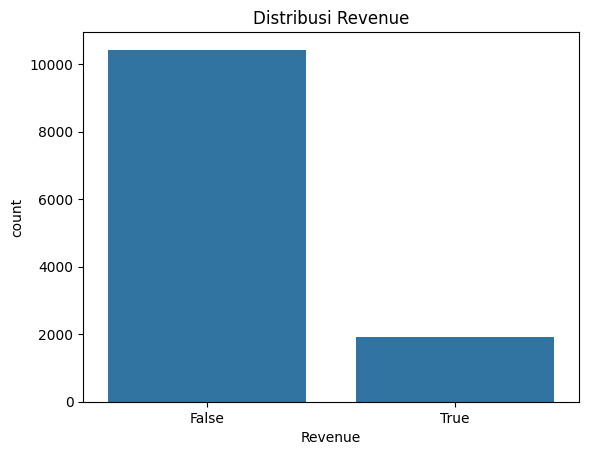

In [ ]:
#visualisasi distribusi kelas target
sns.countplot(x='Revenue', data=df)
plt.title('Distribusi Revenue')

Interpretasi Distribusi Variabel Target (Revenue) :

Berdasarkan grafik distribusi Revenue, terlihat bahwa jumlah data pada kelas Revenue = False jauh lebih banyak dibandingkan dengan Revenue = True. Dari total 12.330 observasi, sekitar 10.422 data (84,53%) termasuk ke dalam kategori False yang menunjukkan bahwa pengunjung tidak melakukan transaksi pembelian, sedangkan sekitar 1.908 data (15,47%) termasuk ke dalam kategori True yang menunjukkan bahwa pengunjung melakukan pembelian.

Perbedaan jumlah data yang cukup besar antara kedua kelas tersebut menunjukkan bahwa dataset mengalami ketidakseimbangan kelas (imbalanced class). Kondisi ini dapat menyebabkan model klasifikasi cenderung lebih mudah memprediksi kelas mayoritas (Revenue = False) dibandingkan kelas minoritas (Revenue = True). Oleh karena itu, pada tahap preprocessing diperlukan teknik penyeimbangan data, seperti SMOTE (Synthetic Minority Over-sampling Technique), agar model dapat mempelajari pola dari kedua kelas secara lebih seimbang dan menghasilkan performa klasifikasi yang lebih baik.

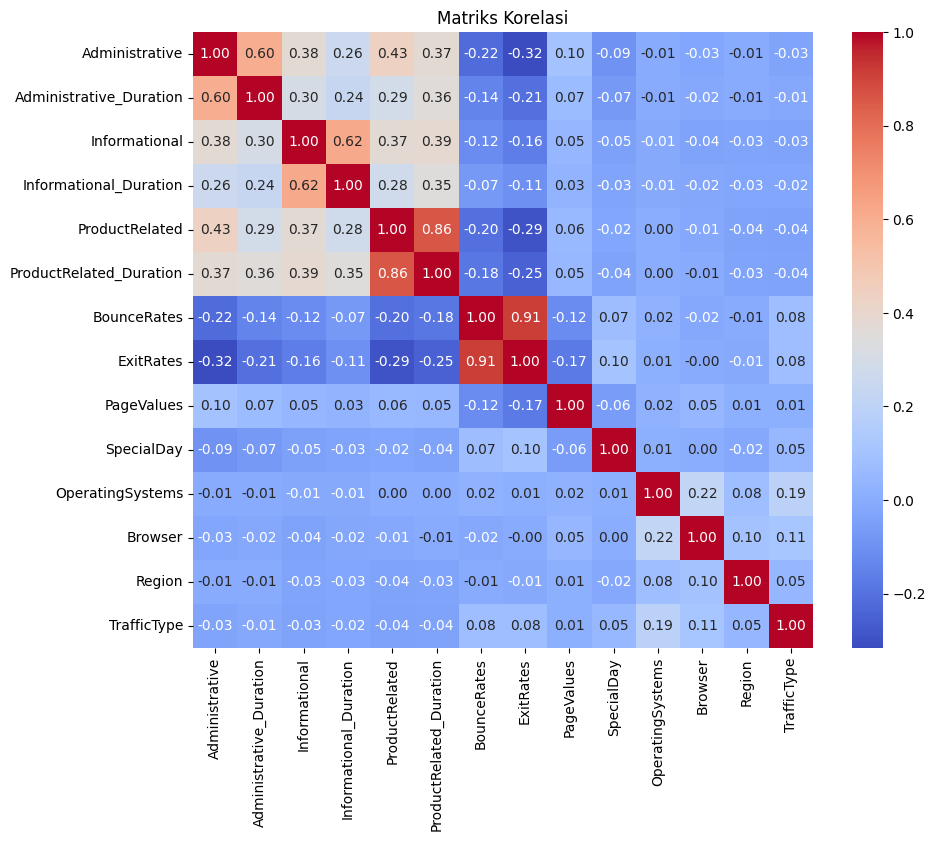

In [ ]:
#visualisasi korelasi antar variabel numerik
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,annot=True,
cmap='coolwarm',fmt=".2f")
plt.title('Matriks Korelasi')
plt.show()

Interpretasi Matriks Korelasi :

Berdasarkan matriks korelasi yang ditampilkan, sebagian besar variabel numerik memiliki hubungan yang lemah hingga sedang. Korelasi positif terkuat ditemukan antara BounceRates dan ExitRates dengan nilai sekitar 0,91, yang menunjukkan bahwa semakin tinggi tingkat pengunjung yang meninggalkan website setelah melihat satu halaman (bounce rate), maka semakin tinggi pula tingkat keluar dari website (exit rate). Selain itu, variabel ProductRelated dan ProductRelated_Duration memiliki korelasi positif yang sangat kuat yaitu sekitar 0,86, yang mengindikasikan bahwa semakin banyak halaman produk yang dikunjungi, semakin lama waktu yang dihabiskan pengunjung pada halaman produk tersebut.

Hubungan yang cukup kuat juga terlihat pada variabel Informational dan Informational_Duration dengan korelasi sekitar 0,62, serta Administrative dan Administrative_Duration dengan korelasi sekitar 0,60. Hal ini menunjukkan bahwa semakin banyak halaman yang dikunjungi pada kategori tertentu, semakin lama pula durasi kunjungan yang dihabiskan. Sementara itu, sebagian besar variabel lain memiliki nilai korelasi yang relatif rendah (mendekati 0), sehingga menunjukkan bahwa hubungan linear antar variabel tersebut tidak terlalu kuat. Secara keseluruhan, matriks korelasi memberikan informasi bahwa tidak semua variabel saling berkaitan secara kuat, namun terdapat beberapa pasangan variabel yang memiliki hubungan erat dan berpotensi memberikan informasi yang serupa dalam proses pemodelan klasifikasi.

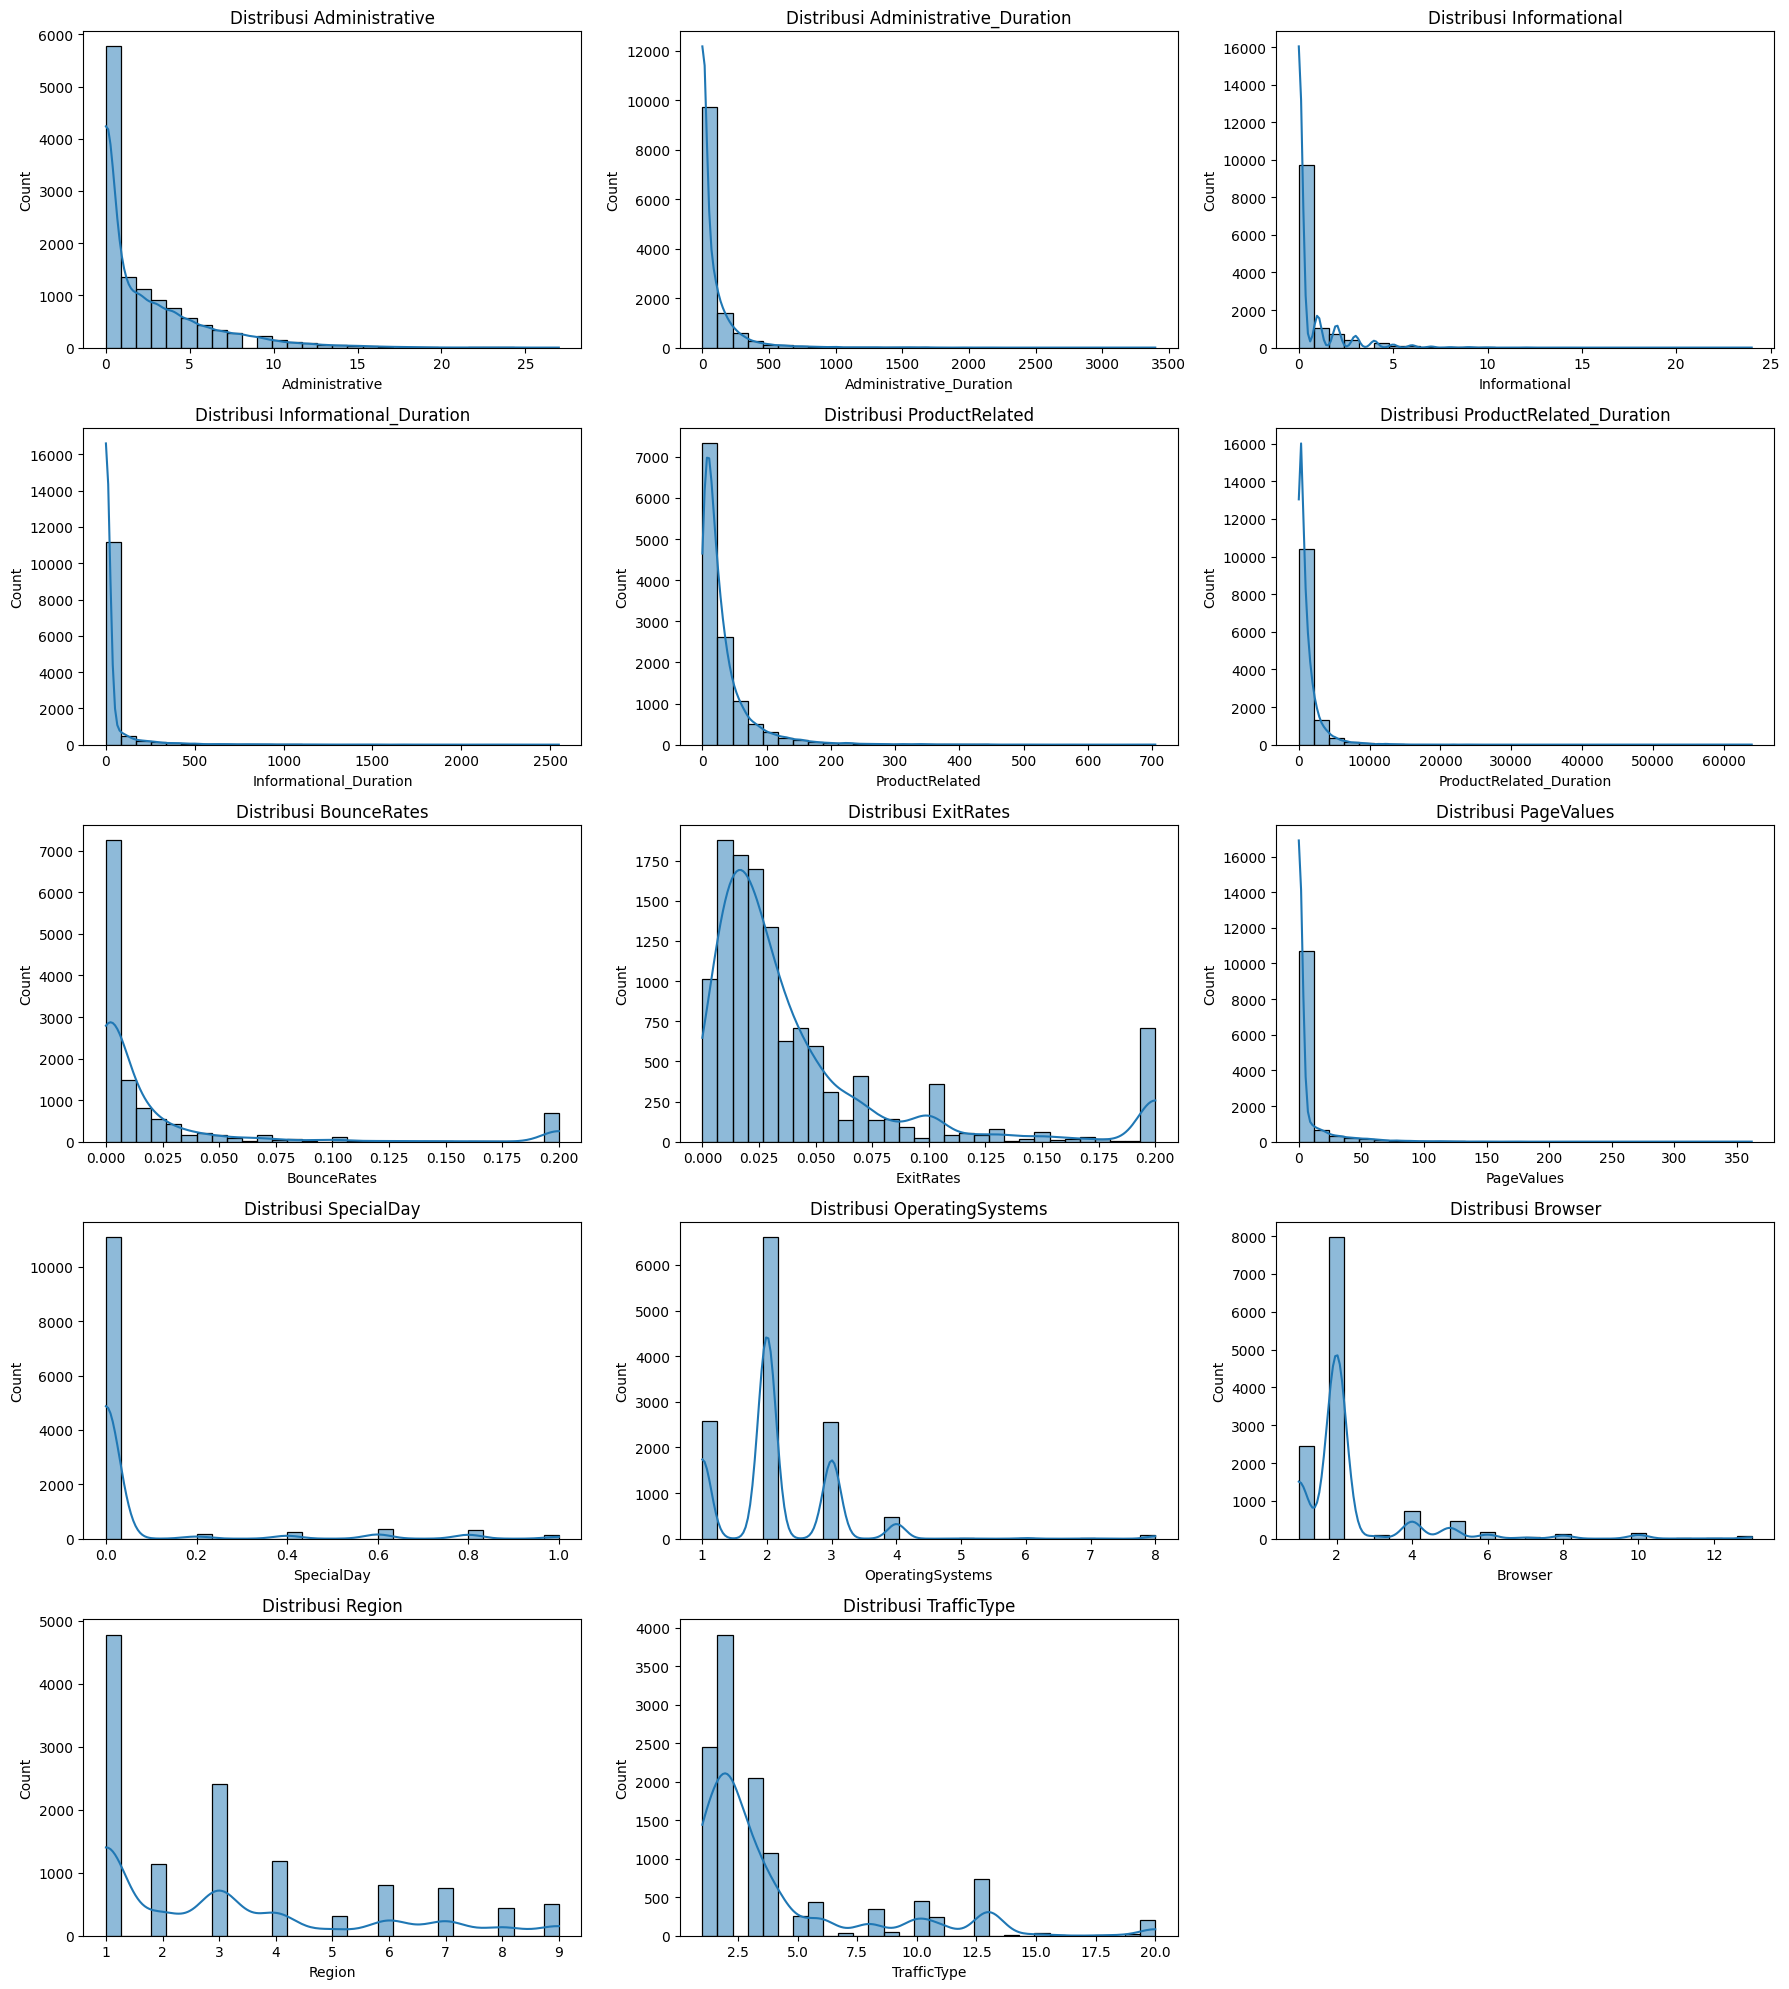

In [ ]:
# 1. Otomatis ambil semua data numerik
kolom_numerik = df.select_dtypes(include=np.number).columns
jumlah_grafik = len(kolom_numerik)

# 2. Tentukan jumlah kolom per baris (maksimal 3)
grafik_per_baris = 3

# Hitung jumlah baris yang dibutuhkan secara otomatis
jumlah_baris = (jumlah_grafik + grafik_per_baris - 1) // grafik_per_baris

# 3. Siapkan kanvas dengan ukuran rasio yang pas (Lebar=18, Tinggi menyesuaikan jumlah baris)
fig, axes = plt.subplots(nrows=jumlah_baris, ncols=grafik_per_baris, figsize=(18, jumlah_baris * 4))

# Ratakan matriks axes agar menjadi array 1 dimensi (mudah diakses dengan indeks)
axes = axes.flatten()

# 4. Loop untuk menggambar histogram
for i, kolom in enumerate(kolom_numerik):
    sns.histplot(data=df, x=kolom, bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {kolom}', fontsize=12)
    axes[i].set_xlabel(kolom)

# 5. Menghapus/menyembunyikan kotak grafik yang kosong jika jumlah data tidak pas kelipatan 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Atur jarak antar kotak agar rapi
plt.tight_layout()
plt.show()

Berikut interpretasi per histogram distribusi variabel numerik berdasarkan grafik :



### 1. Distribusi Administrative

Histogram menunjukkan bahwa sebagian besar pengunjung hanya mengakses sedikit halaman administratif, dengan frekuensi tertinggi berada pada nilai 0–2 halaman. Distribusi data terlihat miring ke kanan (*right skewed*), yang menunjukkan bahwa hanya sebagian kecil pengunjung yang mengakses banyak halaman administratif hingga lebih dari 20 halaman.



### 2. Distribusi Administrative_Duration

Sebagian besar pengunjung menghabiskan waktu yang relatif singkat pada halaman administratif. Frekuensi data sangat terkonsentrasi pada nilai rendah, sedangkan terdapat sejumlah kecil pengunjung yang memiliki durasi kunjungan sangat tinggi hingga lebih dari 3.000 detik. Hal ini menunjukkan adanya variasi perilaku pengguna dalam mengakses halaman administratif.



### 3. Distribusi Informational

Variabel **Informational** didominasi oleh nilai 0, yang menunjukkan bahwa mayoritas pengunjung tidak mengakses halaman informasi. Frekuensi data menurun secara drastis seiring meningkatnya jumlah halaman informasi yang dikunjungi. Distribusi yang sangat miring ke kanan menunjukkan bahwa hanya sedikit pengunjung yang aktif mencari informasi tambahan.


### 4. Distribusi Informational_Duration

Distribusi durasi halaman informasi juga sangat terkonsentrasi pada nilai rendah. Sebagian besar pengunjung menghabiskan waktu yang sangat singkat atau bahkan tidak mengakses halaman informasi sama sekali. Namun terdapat sejumlah kecil observasi dengan durasi yang sangat tinggi hingga lebih dari 2.500 detik.


### 5. Distribusi ProductRelated

Variabel **ProductRelated** menunjukkan bahwa sebagian besar pengunjung mengunjungi kurang dari 50 halaman produk. Frekuensi menurun secara bertahap seiring bertambahnya jumlah halaman yang dikunjungi. Distribusi yang miring ke kanan menunjukkan bahwa hanya sebagian kecil pengguna yang melakukan eksplorasi produk secara intensif.


### 6. Distribusi ProductRelated_Duration

Sebagian besar pengunjung menghabiskan waktu relatif singkat pada halaman produk. Akan tetapi, terdapat beberapa pengunjung dengan durasi yang sangat tinggi hingga lebih dari 60.000 detik. Distribusi yang sangat miring ke kanan ini menunjukkan adanya kelompok kecil pengguna yang melakukan eksplorasi produk secara mendalam.


### 7. Distribusi BounceRates

Histogram menunjukkan bahwa sebagian besar nilai **BounceRates** berada sangat dekat dengan nol. Hal ini berarti mayoritas pengunjung tidak langsung meninggalkan website setelah membuka satu halaman. Namun terdapat sebagian kecil pengunjung dengan nilai bounce rate yang cukup tinggi hingga mendekati 0,20.



### 8. Distribusi ExitRates

Distribusi **ExitRates** memiliki pola yang lebih menyebar dibandingkan BounceRates. Mayoritas data berada pada rentang 0,01–0,05, tetapi terdapat sejumlah observasi dengan nilai yang lebih tinggi hingga mendekati 0,20. Hal ini menunjukkan bahwa sebagian besar pengunjung memiliki kecenderungan keluar website yang relatif rendah.

### 9. Distribusi PageValues

Variabel **PageValues** didominasi oleh nilai nol atau mendekati nol. Hal ini menunjukkan bahwa sebagian besar sesi kunjungan tidak menghasilkan nilai halaman yang signifikan. Namun terdapat beberapa nilai yang sangat tinggi hingga lebih dari 350, yang menunjukkan adanya sejumlah kecil sesi yang memiliki kontribusi besar terhadap potensi transaksi.



### 10. Distribusi SpecialDay

Sebagian besar data memiliki nilai **SpecialDay = 0**, yang menunjukkan bahwa mayoritas kunjungan tidak terjadi mendekati hari-hari spesial atau promosi tertentu. Hanya sebagian kecil observasi yang memiliki nilai antara 0,2 hingga 1,0 sehingga distribusi variabel ini sangat tidak merata.


### 11. Distribusi OperatingSystems

Distribusi **OperatingSystems** menunjukkan bahwa sebagian besar pengunjung menggunakan sistem operasi kategori 2, diikuti kategori 1 dan 3. Kategori sistem operasi lainnya memiliki frekuensi yang jauh lebih rendah. Hal ini menunjukkan bahwa akses website didominasi oleh beberapa jenis sistem operasi tertentu.



### 12. Distribusi Browser

Histogram **Browser** menunjukkan bahwa kategori browser 2 merupakan browser yang paling banyak digunakan oleh pengunjung. Browser kategori lainnya memiliki frekuensi yang lebih rendah dan tersebar pada beberapa kategori. Distribusi ini menunjukkan adanya dominasi browser tertentu dalam aktivitas kunjungan website.


### 13. Distribusi Region

Variabel **Region** menunjukkan bahwa pengunjung berasal dari beberapa wilayah yang berbeda, dengan frekuensi tertinggi pada Region 1 dan Region 3. Sementara itu, wilayah lainnya memiliki jumlah pengunjung yang relatif lebih sedikit. Hal ini menunjukkan bahwa aktivitas pengunjung tidak terdistribusi secara merata pada seluruh wilayah.



### 14. Distribusi TrafficType

Distribusi **TrafficType** menunjukkan bahwa sebagian besar pengunjung berasal dari beberapa sumber trafik tertentu, terutama tipe 2, 3, dan 4. Kategori trafik lainnya memiliki jumlah observasi yang jauh lebih sedikit. Hal ini menunjukkan bahwa website memperoleh sebagian besar kunjungan dari sumber trafik tertentu yang lebih dominan dibandingkan sumber lainnya.


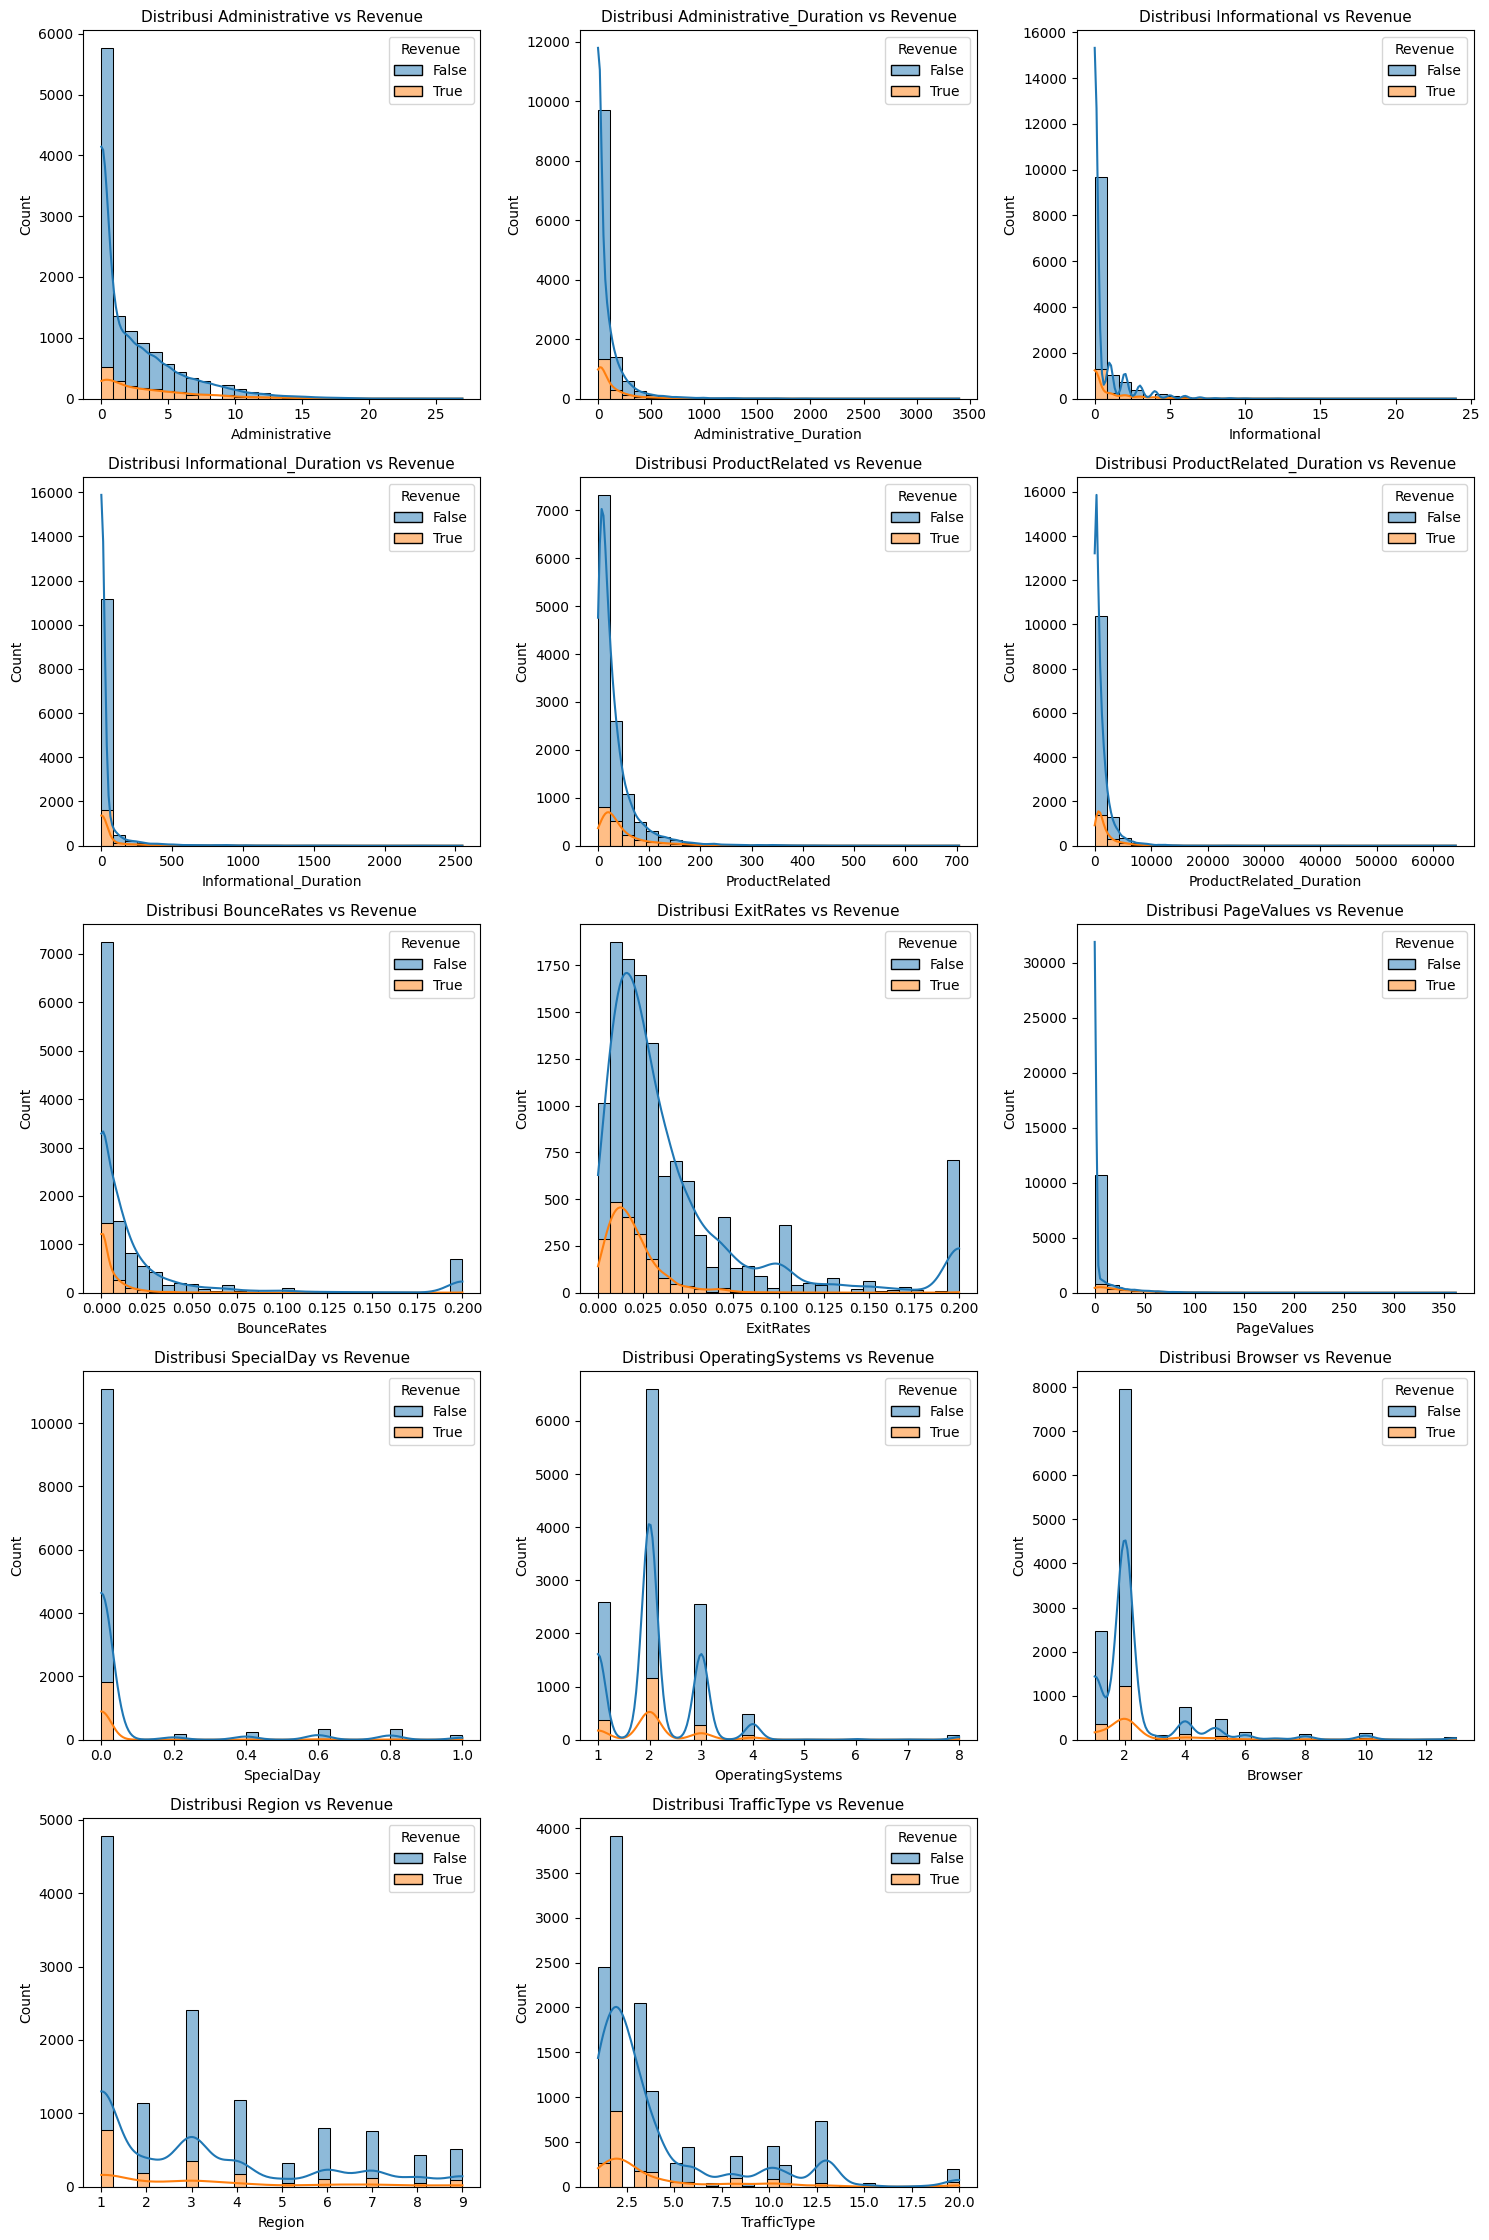

In [ ]:
# 1. Otomatis ambil semua data numerik dari DataFrame
kolom_numerik = df.select_dtypes(include=np.number).columns
jumlah_grafik = len(kolom_numerik)

# 2. Atur layout: maksimal 3 grafik menyamping per baris
grafik_per_baris = 3
jumlah_baris = (jumlah_grafik + grafik_per_baris - 1) // grafik_per_baris

# 3. Siapkan kanvas dengan rasio ukuran kotak yang proporsional
fig, axes = plt.subplots(nrows=jumlah_baris, ncols=grafik_per_baris, figsize=(15, jumlah_baris * 4.5))

# Ratakan matriks axes menjadi array 1 dimensi agar mudah diakses di dalam loop
axes = axes.flatten()

# 4. Loop untuk menggambar histogram berdasarkan Revenue
for i, kolom in enumerate(kolom_numerik):
    # Hitung jumlah nilai unik untuk menyesuaikan jumlah bins (batang)
    jumlah_unik = df[kolom].nunique()

    # Gambar histplot dengan pemisahan warna 'Revenue' (hue)
    # multiple="stack" atau "dodge" bisa ditambahkan jika ingin batang tidak saling menutupi
    sns.histplot(
        data=df,
        x=kolom,
        hue='Revenue',
        bins=30
        ,
        kde=True,
        ax=axes[i],
        multiple="stack"  # Membuat batang menumpuk ke atas agar rasionya tetap proporsional dan jelas
    )

    # Atur judul dan label masing-masing kotak grafik
    axes[i].set_title(f'Distribusi {kolom} vs Revenue', fontsize=11)
    axes[i].set_xlabel(kolom)

# 5. Hapus kotak grid yang kosong/sisa di baris terakhir jika jumlah variabel tidak kelipatan 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Sesuaikan jarak antar kotak grafik agar tidak saling menabrak
plt.tight_layout()
plt.show()

Interpretasi Histogram Variabel Numerik Berdasarkan Revenue :

Berikut interpretasi per grafik yang bisa langsung dimasukkan ke laporan.



### 1. Administrative vs Revenue

Grafik menunjukkan bahwa sebagian besar pengunjung mengakses sedikit halaman administratif, terutama pada rentang 0–5 halaman. Distribusi **Revenue = False** mendominasi seluruh rentang nilai, namun proporsi **Revenue = True** cenderung meningkat pada jumlah halaman administratif yang lebih tinggi. Hal ini mengindikasikan bahwa pengunjung yang melakukan lebih banyak aktivitas administratif, seperti mengakses informasi akun atau transaksi, memiliki peluang lebih besar untuk melakukan pembelian.


### 2. Administrative_Duration vs Revenue

Sebagian besar pengunjung menghabiskan waktu yang relatif singkat pada halaman administratif. Distribusi data terlihat sangat miring ke kanan (*right skewed*) dengan beberapa nilai ekstrem pada durasi yang tinggi. Pengunjung dengan **Revenue = True** cenderung memiliki durasi kunjungan administratif yang lebih lama dibandingkan pengunjung yang tidak melakukan pembelian, sehingga durasi aktivitas administratif dapat menjadi indikator ketertarikan pengguna terhadap proses transaksi.



### 3. Informational vs Revenue

Mayoritas pengunjung tidak mengakses atau hanya mengakses sedikit halaman informasi. Meskipun jumlah pengunjung yang melakukan pembelian tetap lebih kecil dibandingkan yang tidak melakukan pembelian, terlihat bahwa pengunjung dengan **Revenue = True** relatif lebih sering mengakses halaman informasi dibandingkan pengunjung dengan **Revenue = False**. Hal ini menunjukkan bahwa pencarian informasi tambahan dapat berkontribusi terhadap keputusan pembelian.



### 4. Informational_Duration vs Revenue

Distribusi durasi halaman informasi sangat terkonsentrasi pada nilai rendah dengan beberapa observasi bernilai tinggi. Pengunjung yang melakukan pembelian cenderung menghabiskan waktu lebih lama pada halaman informasi dibandingkan yang tidak melakukan pembelian. Kondisi ini menunjukkan bahwa pengunjung yang meluangkan waktu untuk memahami informasi produk atau layanan memiliki kecenderungan lebih tinggi untuk melakukan transaksi.



### 5. ProductRelated vs Revenue

Variabel ini menunjukkan perbedaan yang cukup jelas antara kedua kelas Revenue. Pengunjung dengan **Revenue = True** cenderung mengunjungi lebih banyak halaman produk dibandingkan pengunjung dengan **Revenue = False**. Semakin banyak halaman produk yang diakses, semakin besar kemungkinan terjadinya pembelian, sehingga variabel ini berpotensi menjadi salah satu prediktor penting dalam model klasifikasi.


### 6. ProductRelated_Duration vs Revenue

Distribusi menunjukkan bahwa sebagian besar pengunjung menghabiskan waktu singkat pada halaman produk, namun terdapat sejumlah pengunjung yang menghabiskan waktu sangat lama. Pengunjung dengan **Revenue = True** terlihat lebih banyak berada pada rentang durasi yang lebih tinggi. Hal ini menunjukkan bahwa lamanya waktu yang dihabiskan untuk melihat produk memiliki hubungan positif dengan peluang terjadinya transaksi pembelian.

### 7. BounceRates vs Revenue

Grafik menunjukkan bahwa nilai **BounceRates** yang rendah lebih sering dikaitkan dengan **Revenue = True**, sedangkan nilai yang lebih tinggi didominasi oleh **Revenue = False**. Artinya, pengunjung yang langsung meninggalkan website setelah membuka satu halaman memiliki kemungkinan lebih kecil untuk melakukan pembelian dibandingkan pengunjung yang menjelajahi website lebih lanjut.


### 8. ExitRates vs Revenue

Distribusi **ExitRates** menunjukkan pola yang serupa dengan BounceRates. Pengunjung yang melakukan pembelian cenderung memiliki nilai ExitRates yang lebih rendah, sedangkan pengunjung yang tidak melakukan pembelian lebih banyak berada pada nilai ExitRates yang tinggi. Hal ini mengindikasikan bahwa semakin tinggi kecenderungan pengguna keluar dari website, semakin kecil peluang terjadinya transaksi.


### 9. PageValues vs Revenue

Variabel **PageValues** menunjukkan perbedaan yang paling jelas antara kedua kelas Revenue. Sebagian besar pengunjung yang tidak melakukan pembelian memiliki nilai PageValues mendekati nol, sedangkan pengunjung yang melakukan pembelian lebih banyak ditemukan pada nilai PageValues yang lebih tinggi. Hal ini menunjukkan bahwa PageValues merupakan salah satu variabel yang sangat berpengaruh dalam membedakan pengunjung yang melakukan pembelian dan yang tidak.


### 10. SpecialDay vs Revenue

Sebagian besar data memiliki nilai **SpecialDay = 0**, yang menunjukkan bahwa mayoritas kunjungan tidak terjadi menjelang hari-hari spesial. Tidak terlihat perbedaan yang sangat mencolok antara kelas Revenue = True dan Revenue = False pada variabel ini. Oleh karena itu, pengaruh variabel SpecialDay terhadap keputusan pembelian tampak relatif lebih kecil dibandingkan variabel perilaku pengguna lainnya.


### 11. OperatingSystems vs Revenue

Distribusi pengunjung didominasi oleh **Operating System 2**, diikuti oleh sistem operasi 1 dan 3. Pola distribusi Revenue = True dan Revenue = False pada masing-masing kategori relatif serupa. Hal ini menunjukkan bahwa jenis sistem operasi yang digunakan pengunjung tidak memberikan perbedaan yang terlalu signifikan terhadap peluang terjadinya pembelian.


### 12. Browser vs Revenue

Sebagian besar pengunjung menggunakan **Browser 2**, sedangkan browser lainnya memiliki frekuensi yang lebih rendah. Distribusi Revenue pada setiap browser cenderung mengikuti pola distribusi keseluruhan data sehingga tidak terlihat adanya browser tertentu yang secara kuat berkaitan dengan keputusan pembelian.


### 13. Region vs Revenue

Pengunjung berasal dari berbagai wilayah dengan dominasi pada Region 1 dan Region 3. Meskipun terdapat variasi jumlah pengunjung antar wilayah, pola Revenue = True dan Revenue = False relatif serupa di seluruh region. Oleh karena itu, wilayah pengguna tampaknya bukan faktor utama yang memengaruhi keputusan pembelian.

### 14. TrafficType vs Revenue

Distribusi menunjukkan bahwa sebagian besar pengunjung berasal dari beberapa tipe trafik tertentu, terutama tipe 2 dan 3. Meskipun terdapat perbedaan frekuensi antar tipe trafik, pengunjung yang melakukan pembelian dan yang tidak melakukan pembelian tersebar pada hampir seluruh kategori trafik. Namun demikian, beberapa tipe trafik menunjukkan proporsi pembelian yang relatif lebih tinggi sehingga variabel ini masih berpotensi memberikan kontribusi dalam proses klasifikasi.



**EDA**

boxplot buat cek outliers

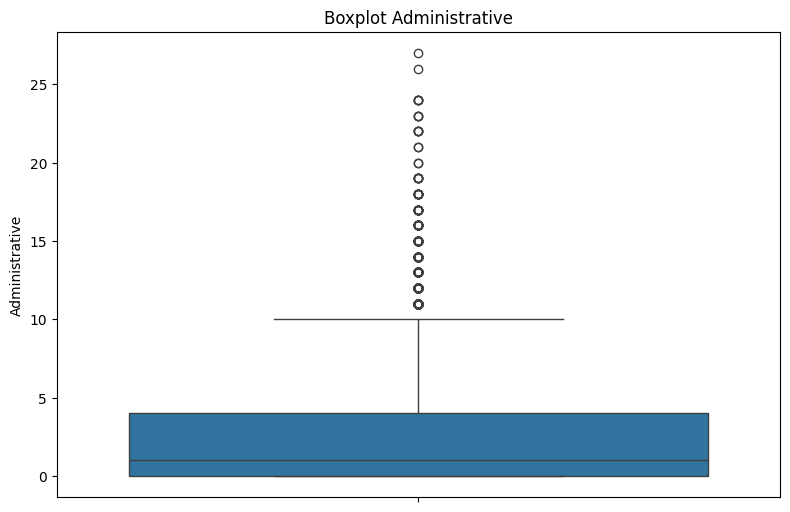

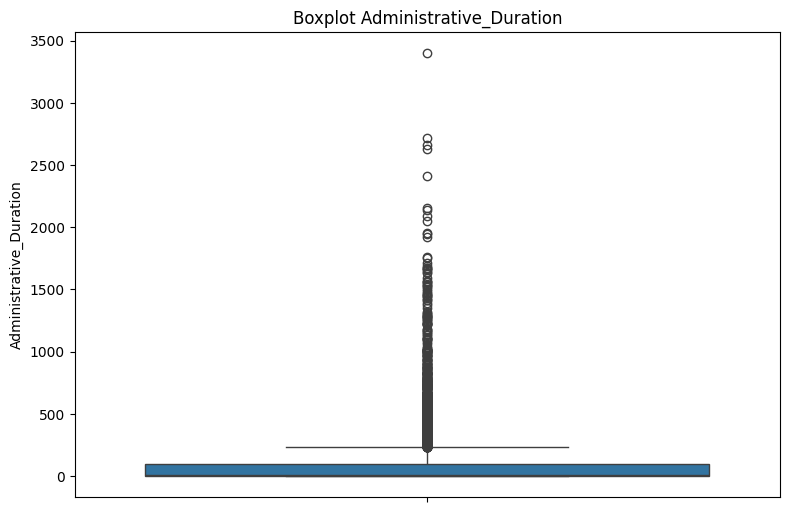

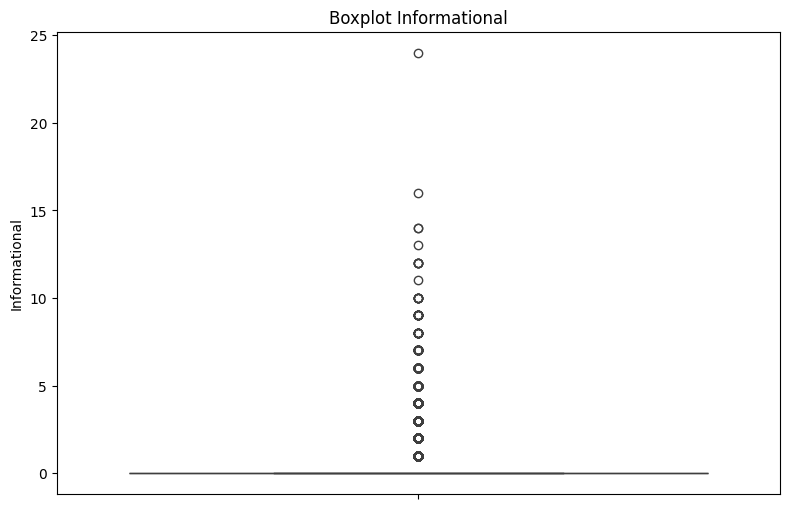

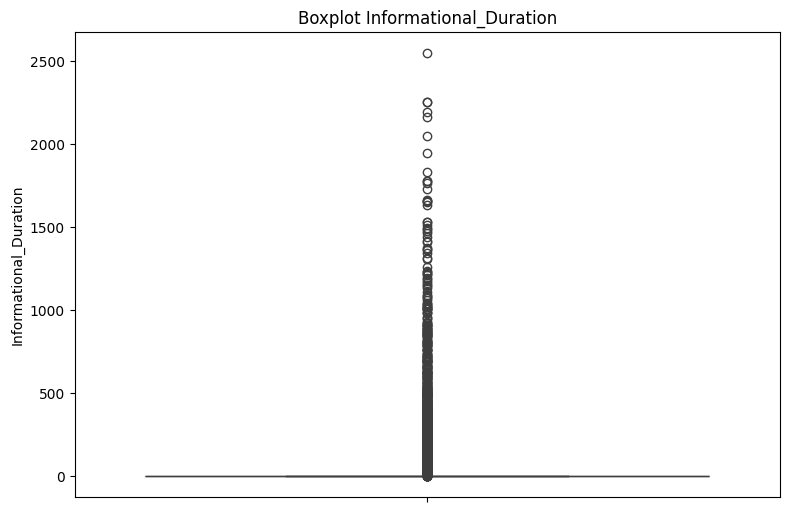

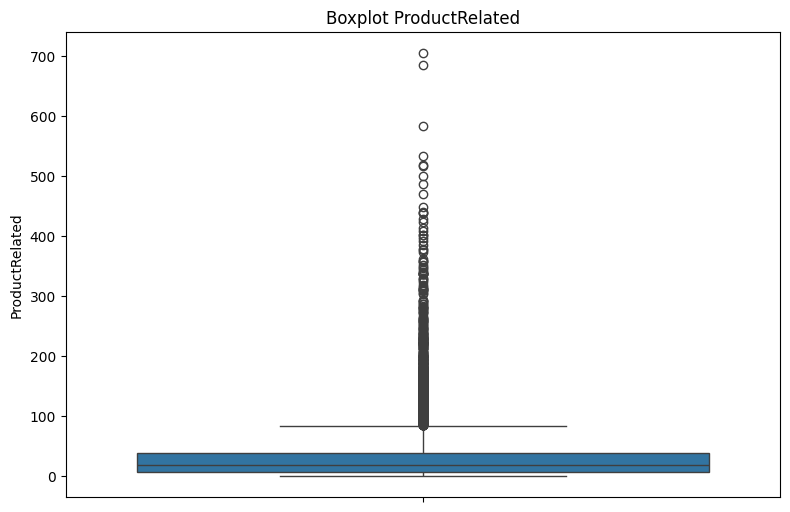

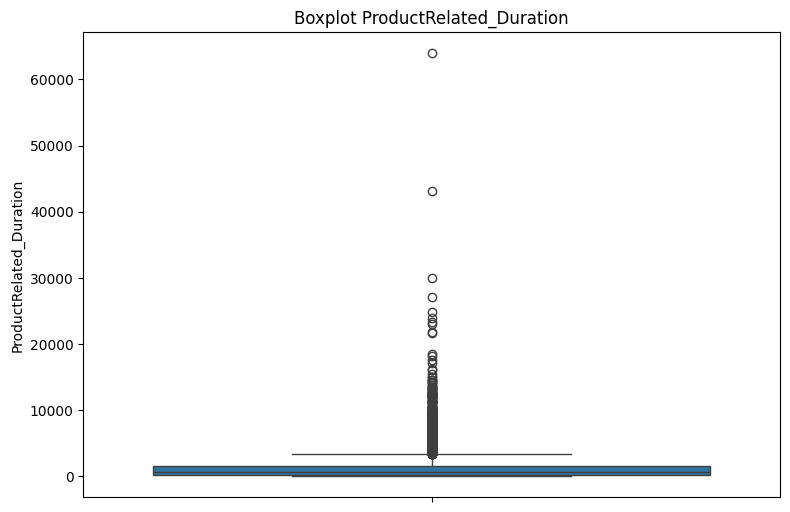

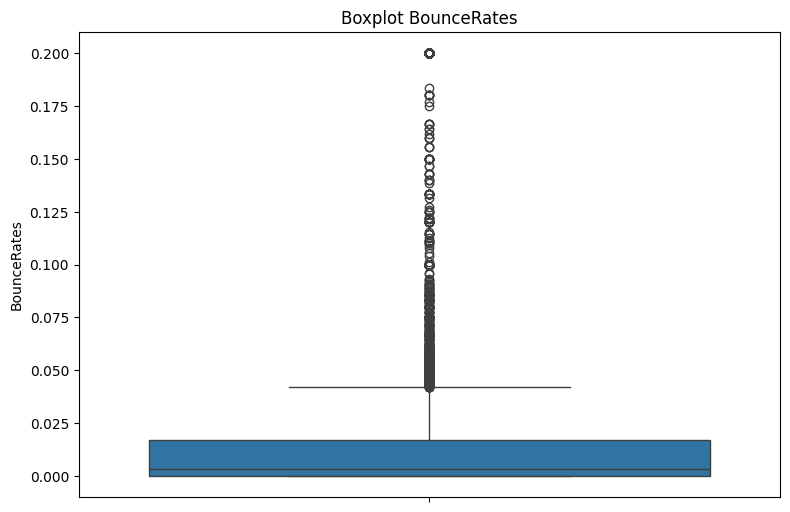

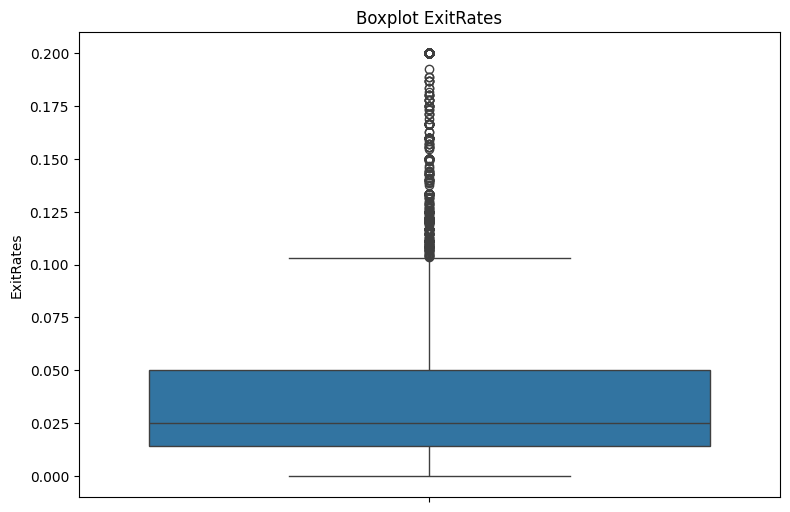

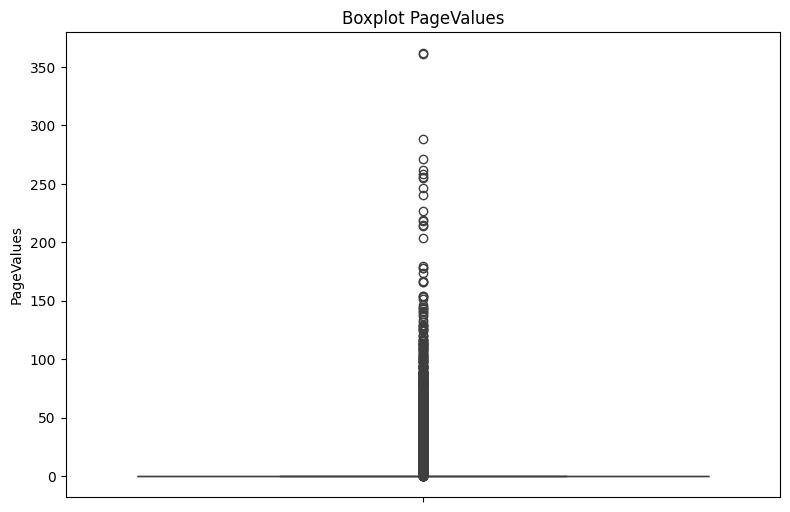

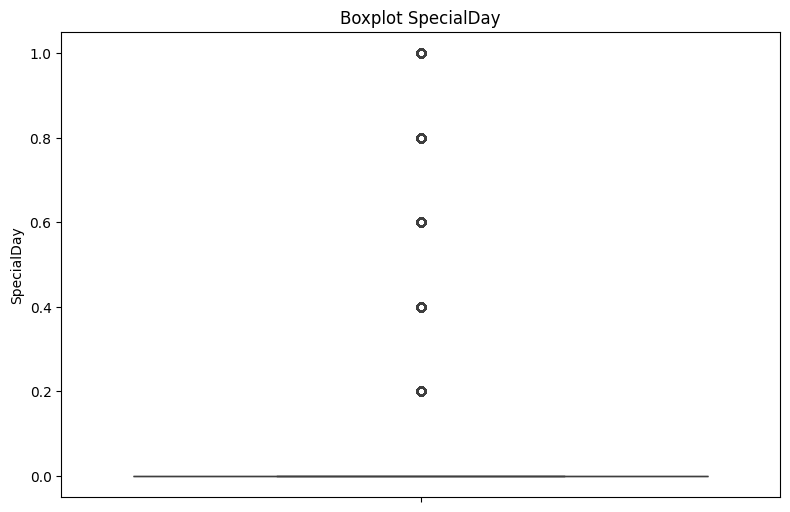

In [ ]:
#histogram variabel numerik bedasarkan revenue
numerik = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]
for kolom in numerik:
    plt.figure(figsize=(8,5))
    sns.boxplot(
    y=df[kolom])

    plt.tight_layout()
    plt.title(f'Boxplot {kolom}')
    plt.show()

Interpretasi Boxplot Variabel Numerik :

Berikut interpretasi **per boxplot** yang dapat langsung dimasukkan ke laporan.

### 1. Boxplot Administrative

Boxplot variabel **Administrative** menunjukkan bahwa mayoritas pengunjung hanya mengunjungi sedikit halaman administratif, dengan median berada pada nilai yang rendah. Terlihat banyak titik outlier di atas batas atas boxplot hingga mencapai lebih dari 25 halaman. Hal ini menunjukkan bahwa terdapat sebagian kecil pengunjung yang melakukan aktivitas administratif jauh lebih banyak dibandingkan mayoritas pengguna.

### 2. Boxplot Administrative_Duration

Variabel **Administrative_Duration** memiliki distribusi yang sangat miring ke kanan (*right skewed*). Sebagian besar data terkonsentrasi pada durasi yang rendah, namun terdapat banyak outlier dengan durasi yang sangat tinggi hingga lebih dari 3.000 detik. Kondisi ini menunjukkan bahwa sebagian besar pengunjung hanya menghabiskan waktu singkat pada halaman administratif, sementara sebagian kecil lainnya menghabiskan waktu yang jauh lebih lama.

### 3. Boxplot Informational

Pada variabel **Informational**, mayoritas data berada pada nilai 0 yang menunjukkan bahwa sebagian besar pengunjung tidak mengakses halaman informasi. Namun, terdapat sejumlah outlier hingga sekitar 24 halaman informasi yang dikunjungi. Hal ini mengindikasikan bahwa hanya sebagian kecil pengunjung yang aktif mencari informasi tambahan sebelum mengambil keputusan.


### 4. Boxplot Informational_Duration

Variabel **Informational_Duration** menunjukkan pola yang serupa dengan Informational. Sebagian besar pengunjung menghabiskan waktu yang sangat singkat atau bahkan tidak mengakses halaman informasi sama sekali. Akan tetapi, terdapat banyak outlier dengan durasi yang sangat tinggi hingga lebih dari 2.500 detik, yang menunjukkan adanya sebagian kecil pengunjung yang melakukan pencarian informasi secara mendalam.

### 5. Boxplot ProductRelated

Variabel **ProductRelated** memiliki median yang lebih tinggi dibandingkan Administrative dan Informational, yang menunjukkan bahwa aktivitas melihat halaman produk merupakan aktivitas utama pengunjung website. Meskipun sebagian besar data berada pada rentang rendah hingga menengah, terdapat banyak outlier dengan jumlah halaman produk yang dikunjungi mencapai lebih dari 700 halaman. Hal ini menunjukkan adanya variasi perilaku yang cukup besar antar pengunjung.



### 6. Boxplot ProductRelated_Duration

Variabel **ProductRelated_Duration** menunjukkan penyebaran data yang sangat luas dengan jumlah outlier yang sangat banyak. Sebagian besar pengunjung menghabiskan waktu relatif singkat pada halaman produk, namun terdapat beberapa pengunjung yang menghabiskan waktu hingga lebih dari 60.000 detik. Kondisi ini menunjukkan adanya kelompok pengguna yang melakukan eksplorasi produk secara sangat intensif sebelum melakukan keputusan pembelian.



### 7. Boxplot BounceRates

Pada variabel **BounceRates**, mayoritas data terkonsentrasi pada nilai yang sangat rendah dengan median mendekati nol. Namun terdapat cukup banyak outlier hingga mendekati nilai 0,20. Hal ini menunjukkan bahwa sebagian besar pengunjung tidak langsung meninggalkan website setelah membuka satu halaman, meskipun terdapat sebagian kecil pengguna yang memiliki tingkat bounce yang cukup tinggi.



### 8. Boxplot ExitRates

Variabel **ExitRates** memiliki median sekitar 0,025 dengan penyebaran data yang lebih besar dibandingkan BounceRates. Terdapat sejumlah outlier hingga mendekati nilai 0,20 yang menunjukkan adanya pengunjung dengan kecenderungan tinggi untuk keluar dari website. Namun secara umum, mayoritas pengunjung memiliki tingkat keluar halaman yang relatif rendah.



### 9. Boxplot PageValues

Boxplot **PageValues** menunjukkan bahwa sebagian besar data memiliki nilai nol atau mendekati nol, yang ditunjukkan oleh box yang sangat dekat dengan sumbu bawah. Akan tetapi terdapat banyak outlier dengan nilai yang sangat tinggi hingga lebih dari 350. Kondisi ini menunjukkan bahwa hanya sebagian kecil halaman yang memberikan nilai signifikan terhadap kemungkinan terjadinya transaksi pembelian.


### 10. Boxplot SpecialDay

Variabel **SpecialDay** menunjukkan bahwa mayoritas observasi memiliki nilai 0, yang berarti sebagian besar kunjungan tidak terjadi menjelang hari-hari spesial atau promosi tertentu. Titik-titik yang muncul pada nilai 0,2; 0,4; 0,6; 0,8; dan 1 merupakan outlier yang menunjukkan sebagian kecil kunjungan terjadi pada periode yang lebih dekat dengan hari spesial. Hal ini mengindikasikan bahwa faktor hari spesial hanya memengaruhi sebagian kecil data dalam dataset.


In [ ]:
#Menampilkan jenis data sebelum transformasi
df.info()
#Membuat objek LabelEncoder
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
#Mengubah Weekend menjadi biner
df['Weekend'] = le.fit_transform(df['Weekend'])
df['Revenue']=le.fit_transform(df['Revenue'])
#labeling data month dan visitor type
df=pd.get_dummies(df,columns=['Month','VisitorType'])
#Menampilkan jenis data setelah transformasi
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

Interpretasi Output Transformasi Data

Berdasarkan output df.info(), dapat dilihat bahwa dataset memiliki 12.330 observasi yang seluruhnya lengkap (tidak terdapat nilai kosong atau missing values), baik sebelum maupun setelah proses transformasi data. Hal ini ditunjukkan oleh jumlah Non-Null Count yang sama dengan jumlah observasi pada setiap variabel.

Sebelum transformasi, dataset terdiri atas 18 variabel dengan tipe data yang beragam, yaitu 7 variabel bertipe integer (int64), 7 variabel bertipe numerik kontinu (float64), 2 variabel kategorik (object) yaitu Month dan VisitorType, serta 2 variabel bertipe boolean (bool) yaitu Weekend dan Revenue. Keberadaan variabel bertipe object menunjukkan bahwa masih terdapat data kategorik yang belum dapat langsung digunakan oleh sebagian besar algoritma machine learning.

Setelah dilakukan transformasi menggunakan Label Encoding dan One-Hot Encoding, jumlah variabel meningkat dari 18 menjadi 29 variabel. Variabel Weekend dan Revenue yang sebelumnya bertipe boolean berhasil dikonversi menjadi tipe numerik (int64) dengan representasi nilai 0 dan 1. Selain itu, variabel kategorik Month dan VisitorType diubah menjadi beberapa variabel dummy menggunakan metode One-Hot Encoding. Variabel Month menghasilkan 10 variabel baru, yaitu Month_Aug, Month_Dec, Month_Feb, Month_Jul, Month_June, Month_Mar, Month_May, Month_Nov, Month_Oct, dan Month_Sep. Sementara itu, variabel VisitorType menghasilkan 3 variabel dummy, yaitu VisitorType_New_Visitor, VisitorType_Other, dan VisitorType_Returning_Visitor.

Hasil transformasi menunjukkan bahwa tidak ada lagi variabel bertipe object, sehingga seluruh data telah berada dalam format numerik yang terdiri atas 9 variabel bertipe int64, 7 variabel bertipe float64, dan 13 variabel bertipe bool. Dengan demikian, dataset telah siap digunakan pada tahap analisis lanjutan maupun pemodelan machine learning karena seluruh variabel telah berada dalam format yang dapat diproses oleh algoritma komputasi.

In [ ]:
#Cek Missing value summary untuk tiap variabel
missing = df.isna().sum().sort_values(ascending=False)
print('Missing values (top 20):')
display(missing.head(10))
#Cek nilai negatif pada numerik variabel
num_cols_tmp = df.select_dtypes(include=np.number).columns
if len(num_cols_tmp) > 0:
    neg_counts = (df[num_cols_tmp] < 0).sum().sort_values(ascending=False)
    print('\nCek nilai negatif (top 10):')
    display(neg_counts.head(10))

Missing values (top 20):


,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0



Cek nilai negatif (top 10):


,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


Interpretasi Hasil Pemeriksaan

Missing Value dan Nilai Negatif
Berdasarkan hasil pemeriksaan kualitas data, diketahui bahwa seluruh variabel yang ditampilkan memiliki nilai 0 pada pengecekan missing values. Hal ini menunjukkan bahwa tidak terdapat data yang hilang (missing values) pada variabel Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues, dan SpecialDay. Dengan kata lain, seluruh 12.330 observasi memiliki data yang lengkap sehingga tidak diperlukan proses penanganan missing value seperti imputasi atau penghapusan data.

Selain itu, hasil pemeriksaan nilai negatif menunjukkan bahwa seluruh variabel numerik yang diperiksa juga memiliki jumlah nilai negatif sebesar 0. Artinya, tidak ditemukan nilai yang berada di bawah nol pada variabel-variabel tersebut. Kondisi ini sesuai dengan karakteristik data, karena variabel seperti jumlah halaman yang dikunjungi (Administrative, Informational, ProductRelated), durasi kunjungan, serta metrik perilaku pengguna seperti BounceRates dan ExitRates secara logis memang tidak dapat bernilai negatif.

Secara keseluruhan, hasil pemeriksaan menunjukkan bahwa dataset memiliki kualitas data yang baik karena tidak mengandung missing values maupun nilai negatif yang tidak wajar. Oleh karena itu, data dapat langsung digunakan pada tahap analisis eksploratif dan pemodelan tanpa memerlukan proses pembersihan data tambahan terkait kedua permasalahan tersebut.

In [ ]:
# Memeriksa jumlah baris dan kolom dataset
print("Jumlah baris dan kolom:", df.shape)
# Menampilkan jumlah observasi
print("Jumlah data pelanggan:", df.shape[0])
# Menampilkan jumlah variabel
print("Jumlah variabel:", df.shape[1])

Jumlah baris dan kolom: (12330, 29)
Jumlah data pelanggan: 12330
Jumlah variabel: 29


Interpretasi Jumlah Baris dan Kolom Dataset

Berdasarkan output yang diperoleh, dataset memiliki ukuran sebesar (12.330, 29). Angka pertama menunjukkan jumlah baris atau observasi sebanyak 12.330 data, sedangkan angka kedua menunjukkan jumlah kolom atau variabel sebanyak 29 variabel. Jumlah variabel yang lebih banyak dibandingkan dataset awal terjadi karena proses transformasi data, khususnya One-Hot Encoding pada variabel kategorik Month dan VisitorType, yang menghasilkan beberapa variabel dummy baru.
Output juga menunjukkan bahwa jumlah data pelanggan yang tersedia dalam dataset adalah 12.330 pelanggan atau sesi kunjungan, yang berarti terdapat 12.330 observasi yang dapat digunakan dalam proses analisis dan pemodelan.

Selanjutnya, jumlah variabel yang digunakan dalam dataset adalah 29 variabel, yang terdiri atas variabel numerik asli serta variabel dummy hasil transformasi. Banyaknya variabel ini memberikan informasi yang lebih rinci mengenai karakteristik perilaku pengunjung situs web, seperti aktivitas pada halaman administrasi, halaman produk, sistem operasi yang digunakan, jenis pengunjung, hingga periode kunjungan.

Secara keseluruhan, hasil tersebut menunjukkan bahwa dataset memiliki ukuran yang cukup besar dengan 12.330 observasi dan 29 variabel, sehingga menyediakan informasi yang memadai untuk melakukan analisis eksploratif data maupun membangun model machine learning guna memprediksi perilaku pembelian pelanggan (Revenue).

In [ ]:
# Memeriksa distribusi variabel target revenue
print("\nDistribusi variabel Revenue:")
print(df["Revenue"].value_counts())
# Menampilkan persentase distribusi revenue
print("\nPersentase distribusi Revenue:")
print(df["Revenue"].value_counts(normalize=True) * 100)


Distribusi variabel Revenue:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Persentase distribusi Revenue:
Revenue
0    84.525547
1    15.474453
Name: proportion, dtype: float64


Interpretasi Distribusi Variabel Target Revenue

Berdasarkan output yang diperoleh, variabel target Revenue memiliki dua kategori, yaitu nilai 0 yang menunjukkan pengunjung tidak melakukan pembelian dan nilai 1 yang menunjukkan pengunjung melakukan pembelian.

Hasil distribusi menunjukkan bahwa dari total 12.330 observasi, terdapat 10.422 observasi (84,53%) yang termasuk ke dalam kategori Revenue = 0, sedangkan 1.908 observasi (15,47%) termasuk ke dalam kategori Revenue = 1. Dengan demikian, sebagian besar pengunjung situs web tidak melakukan transaksi pembelian selama kunjungan mereka.

Persentase distribusi tersebut mengindikasikan adanya ketidakseimbangan kelas (class imbalance) pada variabel target. Kelas mayoritas adalah Revenue = 0 dengan proporsi sekitar 84,53%, sedangkan kelas minoritas adalah Revenue = 1 dengan proporsi sekitar 15,47%. Ketidakseimbangan ini perlu diperhatikan pada tahap pemodelan karena dapat menyebabkan model cenderung memprediksi kelas mayoritas dan menghasilkan performa yang kurang baik dalam mengidentifikasi pelanggan yang benar-benar melakukan pembelian.

**PREPOCESSING**

In [ ]:
df.isna().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


Interpretasi Hasil Pemeriksaan Nilai Nol pada Dataset :

Berdasarkan output yang ditampilkan, seluruh variabel memiliki nilai 0. Hasil ini menunjukkan bahwa tidak terdapat permasalahan pada data yang diperiksa, karena angka nol tersebut merepresentasikan jumlah kasus yang dicari oleh sintaks pemeriksaan. Dengan kata lain, tidak ditemukan adanya data yang memenuhi kriteria pengecekan pada setiap variabel.
Pada variabel numerik seperti Administrative, Administrative_Duration, Informational, ProductRelated, BounceRates, ExitRates, PageValues, dan SpecialDay, jumlah kasus yang diperiksa bernilai nol. Demikian pula pada variabel hasil transformasi seperti Month_Aug, Month_Dec, Month_Feb, hingga VisitorType_Returning_Visitor, tidak ditemukan data yang bermasalah berdasarkan kriteria pengecekan yang digunakan.
Selain itu, variabel target Revenue dan variabel Weekend juga menunjukkan nilai nol, yang mengindikasikan tidak adanya permasalahan data pada kedua variabel tersebut. Hasil ini memperlihatkan bahwa proses transformasi data yang telah dilakukan sebelumnya berjalan dengan baik dan tidak menghasilkan nilai yang tidak sesuai.
Secara keseluruhan, hasil pemeriksaan menunjukkan bahwa dataset berada dalam kondisi yang baik karena tidak ditemukan data yang bermasalah pada seluruh 29 variabel yang digunakan. Dengan demikian, dataset telah memenuhi aspek kualitas data yang diperiksa dan dapat digunakan untuk tahap analisis eksploratif maupun pemodelan machine learning tanpa memerlukan proses pembersihan tambahan terkait hasil pengecekan tersebut.

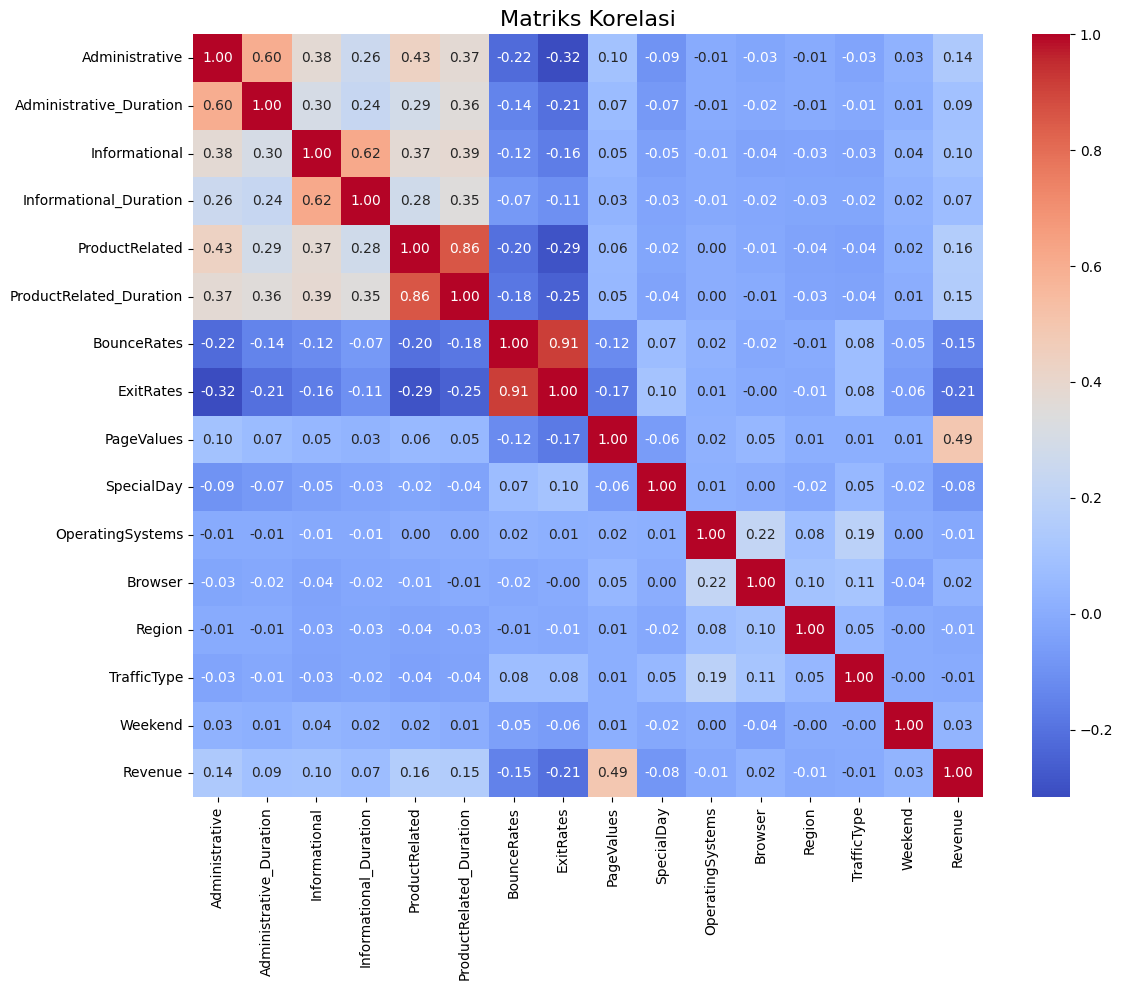

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(12, 10)) # Increased figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10}) # Added annot_kws for font size
plt.title('Matriks Korelasi', fontsize=16) # Increased title font size
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Interpretasi Matriks Korelasi Antar Variabel

Berdasarkan matriks korelasi, hubungan positif terkuat ditemukan antara ProductRelated dan ProductRelated_Duration dengan nilai korelasi sebesar 0,86. Hal ini menunjukkan bahwa semakin banyak halaman produk yang dikunjungi oleh pengguna, maka semakin lama pula waktu yang dihabiskan pada halaman produk tersebut. Selain itu, variabel BounceRates dan ExitRates memiliki korelasi positif yang sangat kuat sebesar 0,91, yang mengindikasikan bahwa halaman dengan tingkat bounce rate yang tinggi cenderung juga memiliki tingkat exit rate yang tinggi.

Beberapa variabel juga menunjukkan korelasi positif sedang, seperti Informational dengan Informational_Duration sebesar 0,62, serta Administrative dengan Administrative_Duration sebesar 0,60. Hubungan ini menunjukkan bahwa semakin banyak halaman yang dikunjungi pada kategori tertentu, maka semakin lama waktu yang dihabiskan pengguna pada kategori halaman tersebut.

Jika dilihat terhadap variabel target Revenue, variabel yang memiliki hubungan positif paling kuat adalah PageValues dengan nilai korelasi sebesar 0,49. Hal ini menunjukkan bahwa semakin tinggi nilai halaman yang dikunjungi pengguna, maka semakin besar kemungkinan pengguna melakukan pembelian. Selain itu, variabel ProductRelated (0,16), ProductRelated_Duration (0,15), dan Administrative (0,14) juga memiliki hubungan positif terhadap Revenue, meskipun kekuatannya relatif lemah hingga sedang.

Sebaliknya, terdapat beberapa variabel yang memiliki hubungan negatif terhadap Revenue. Variabel ExitRates memiliki korelasi sebesar -0,21, sedangkan BounceRates sebesar -0,15. Nilai ini menunjukkan bahwa semakin tinggi tingkat pengunjung meninggalkan situs atau keluar dari halaman tanpa melanjutkan aktivitas, maka semakin kecil kemungkinan terjadinya transaksi pembelian. Variabel SpecialDay juga menunjukkan hubungan negatif yang sangat lemah terhadap Revenue dengan nilai korelasi sebesar -0,08.

Secara keseluruhan, matriks korelasi menunjukkan bahwa sebagian besar variabel memiliki hubungan yang relatif lemah hingga sedang terhadap variabel target Revenue. Namun demikian, PageValues merupakan variabel yang memiliki hubungan paling kuat dengan Revenue, sedangkan BounceRates dan ExitRates menunjukkan hubungan negatif yang mengindikasikan penurunan peluang pembelian. Selain itu, korelasi yang sangat tinggi antara ProductRelated dan ProductRelated_Duration serta antara BounceRates dan ExitRates perlu diperhatikan karena dapat mengindikasikan adanya multikolinearitas, yaitu kondisi ketika dua variabel memberikan informasi yang sangat mirip dalam model prediksi. Oleh karena itu, hasil analisis korelasi ini dapat digunakan sebagai dasar dalam proses seleksi variabel sebelum membangun model machine learning.

feature importance

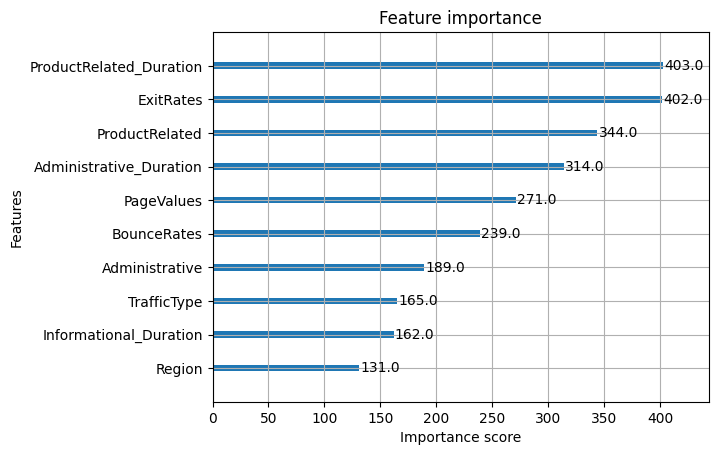

['PageValues', np.float32(0.2306758)]


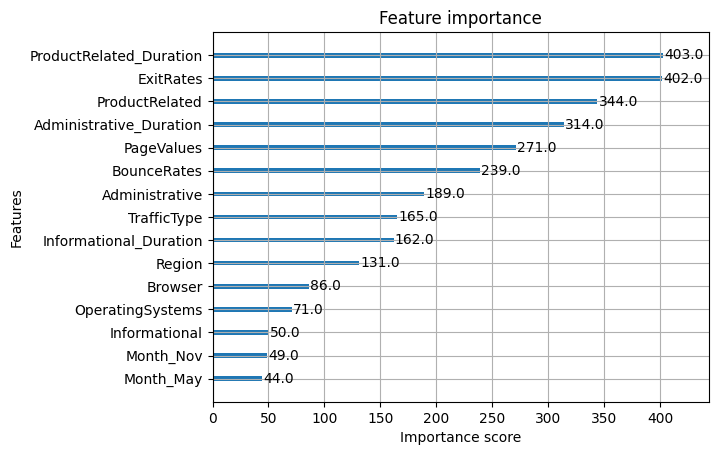

['VisitorType_Returning_Visitor', np.float32(0.119744144)]


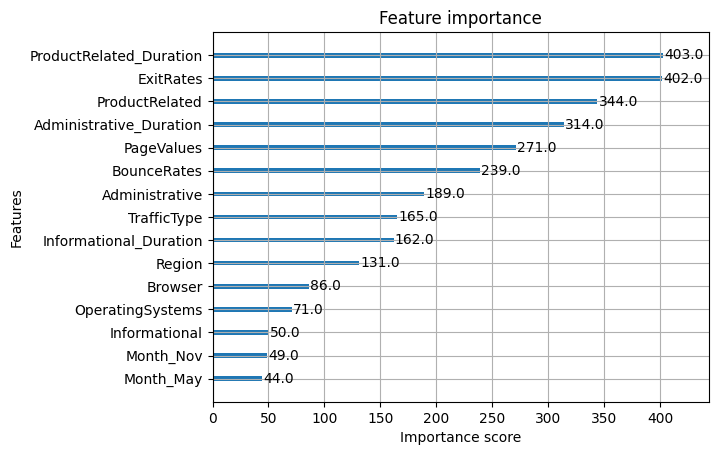

['Month_Nov', np.float32(0.10752793)]


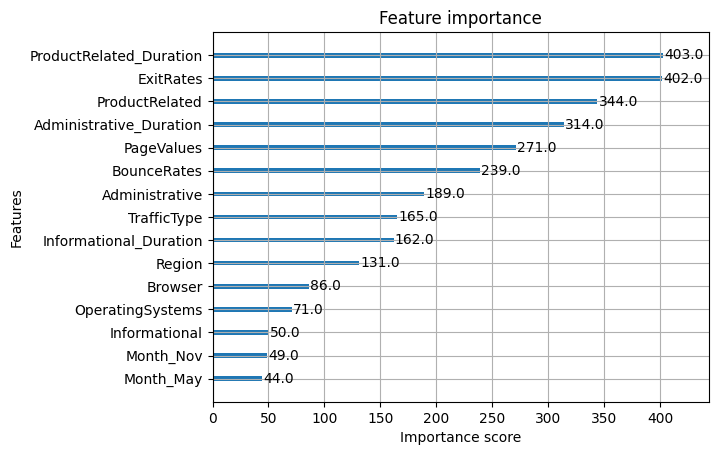

['Month_Mar', np.float32(0.06289116)]


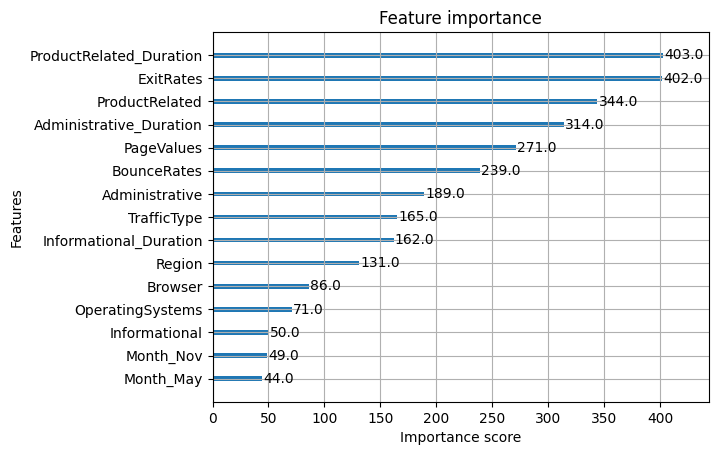

['Month_May', np.float32(0.046967275)]


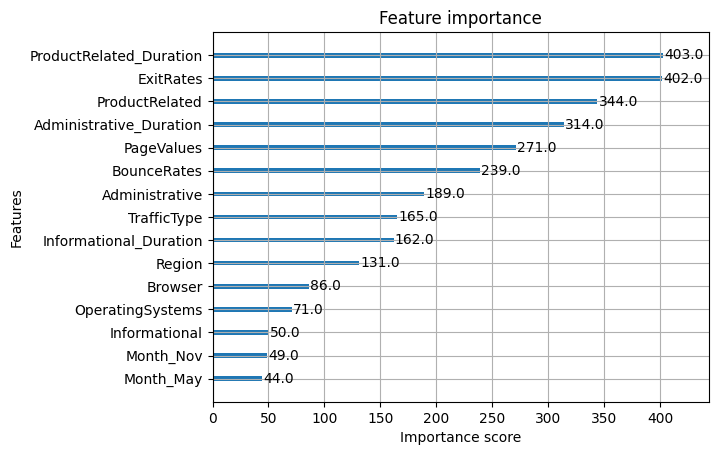

['BounceRates', np.float32(0.029581228)]


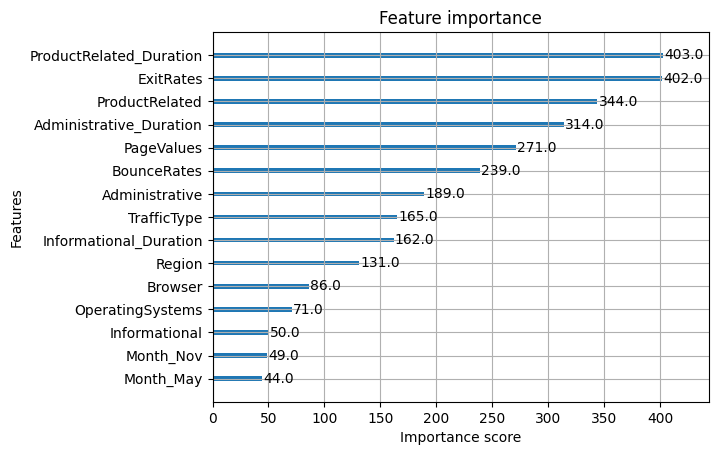

['Month_Sep', np.float32(0.02765224)]


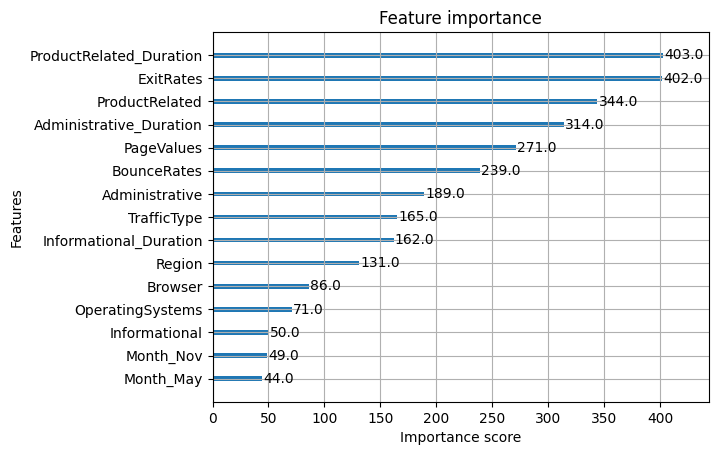

['Administrative', np.float32(0.026248893)]


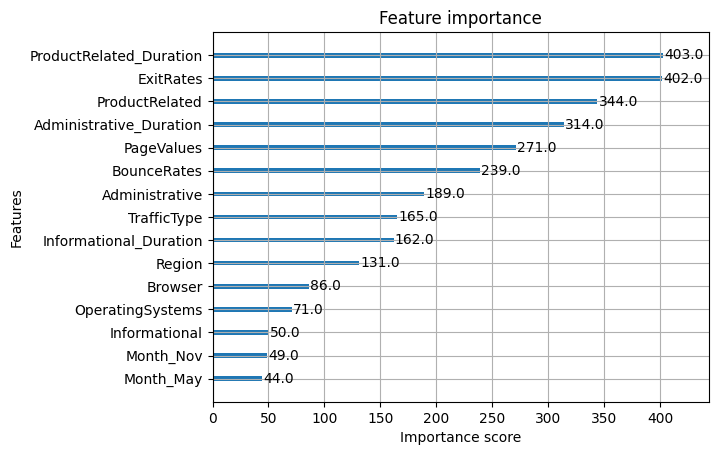

['Month_Jul', np.float32(0.026230756)]


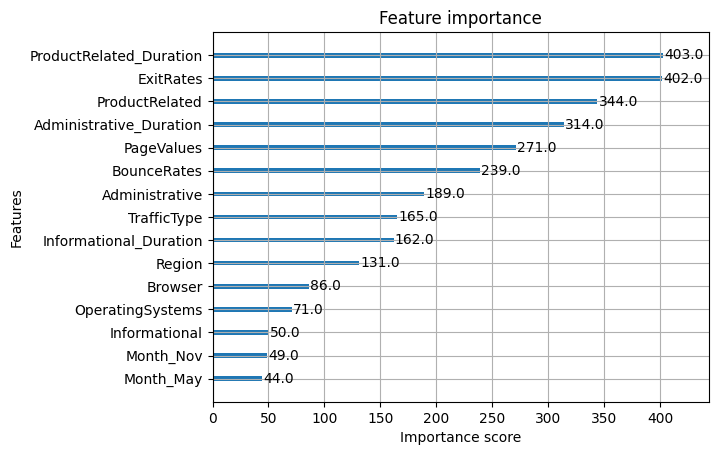

['Month_Dec', np.float32(0.022950763)]


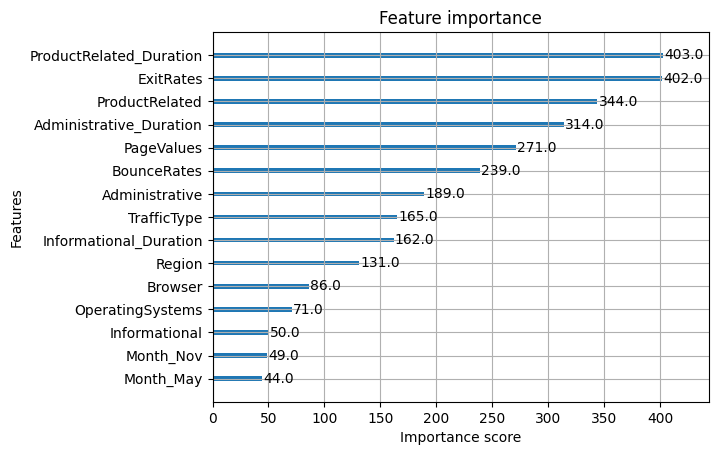

['VisitorType_New_Visitor', np.float32(0.022333594)]


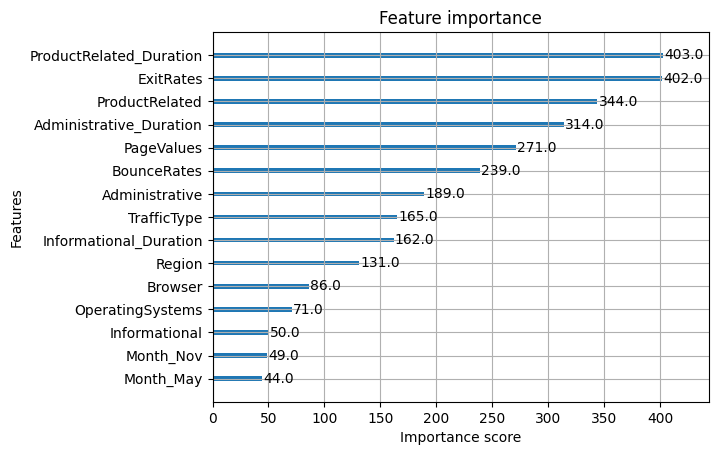

['ProductRelated_Duration', np.float32(0.021609265)]


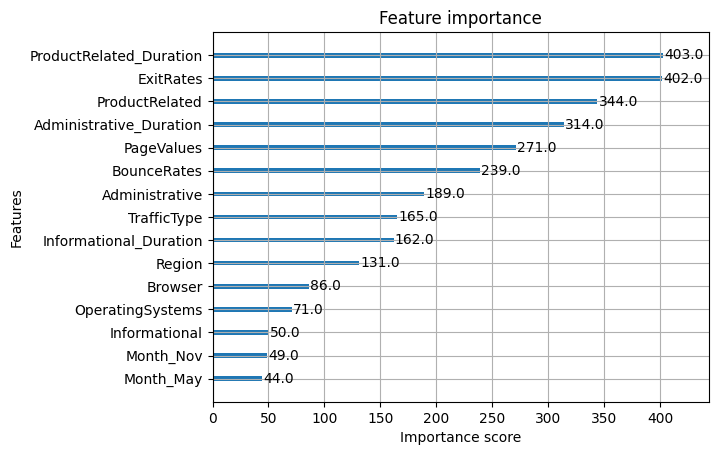

['Weekend', np.float32(0.020045303)]


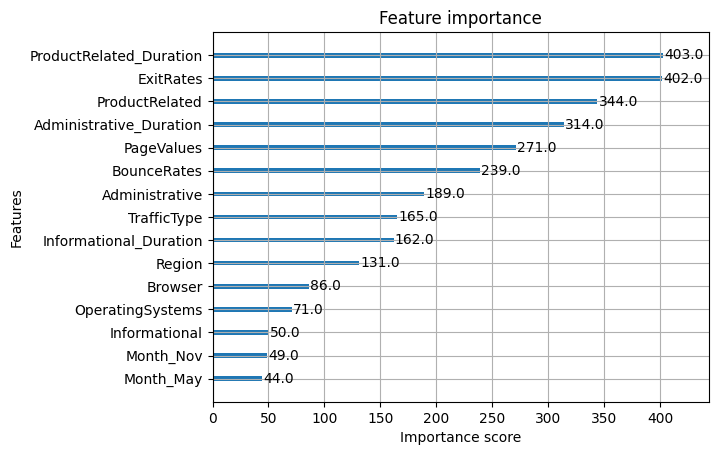

['Informational', np.float32(0.019636363)]


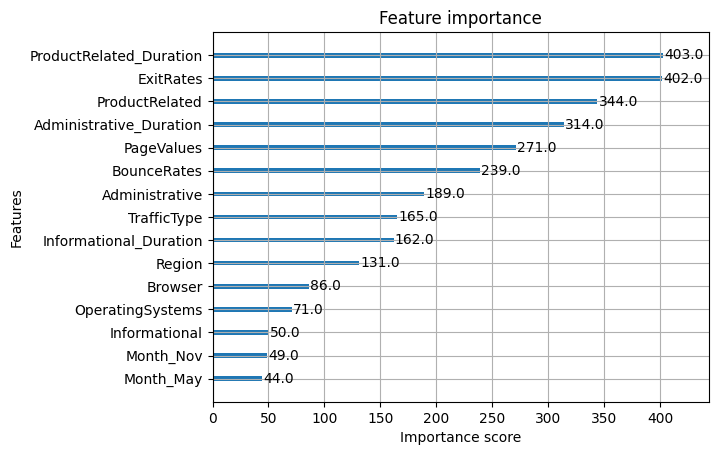

['ProductRelated', np.float32(0.019581687)]


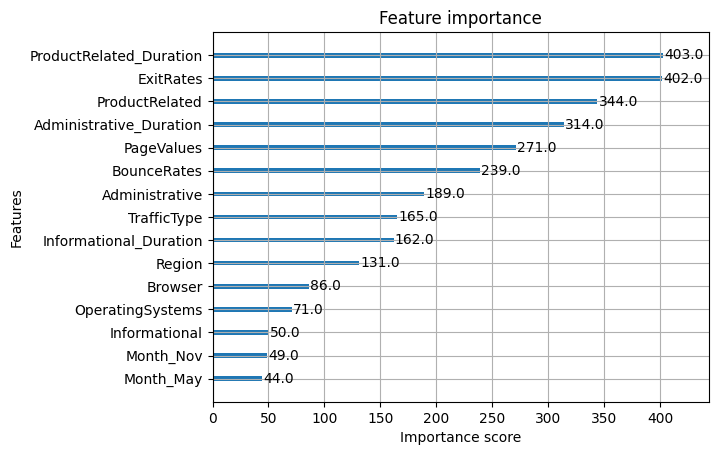

['Administrative_Duration', np.float32(0.019260274)]


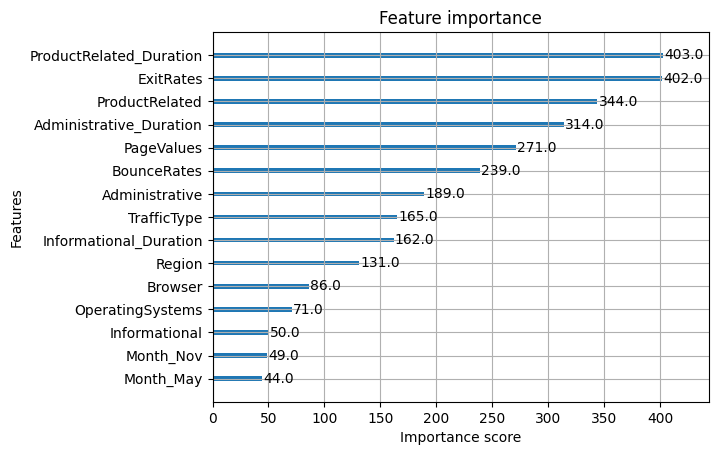

['ExitRates', np.float32(0.01894812)]


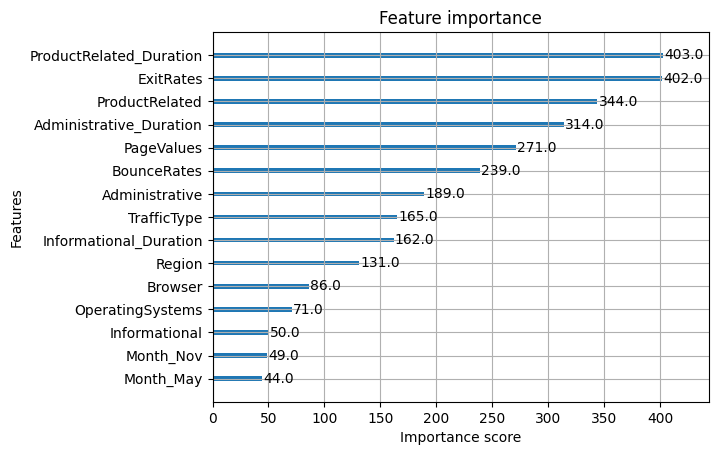

['Month_Aug', np.float32(0.018523471)]


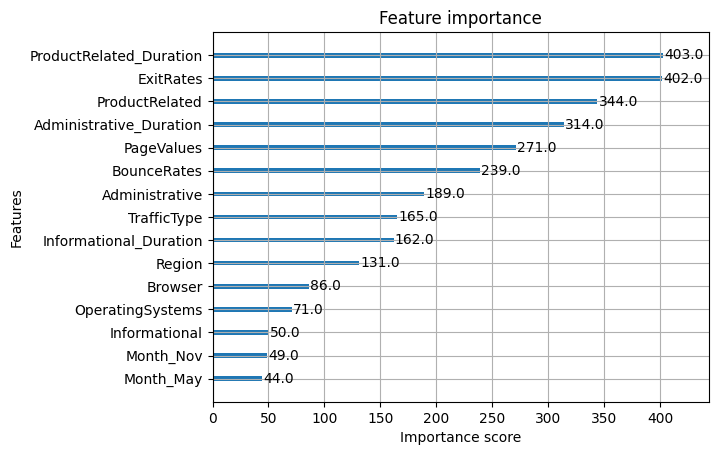

['Informational_Duration', np.float32(0.017882062)]


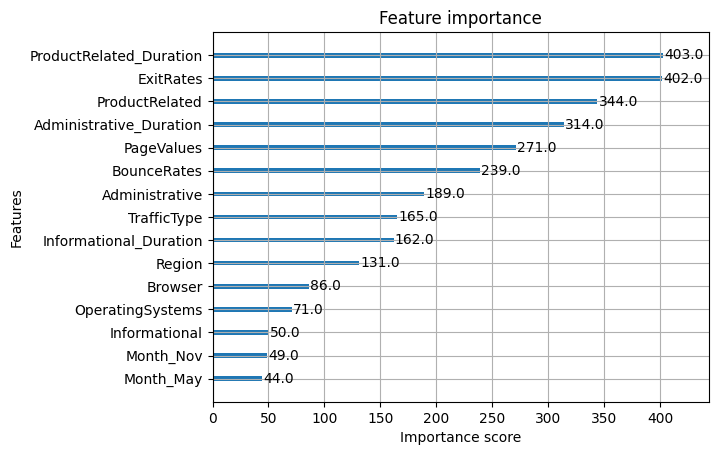

['SpecialDay', np.float32(0.017487893)]


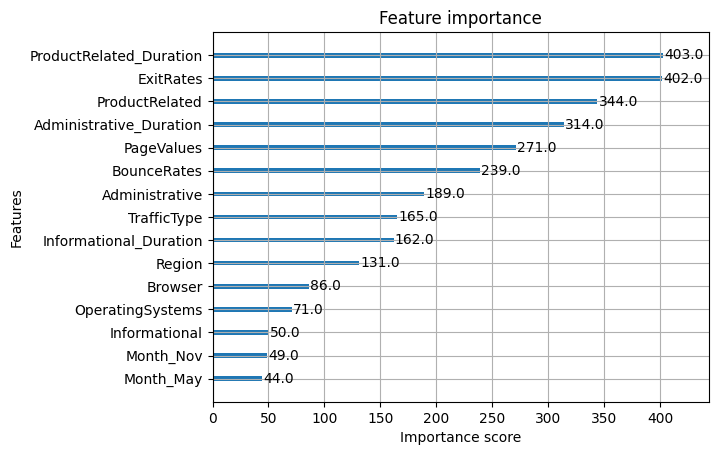

['Month_Oct', np.float32(0.017255742)]


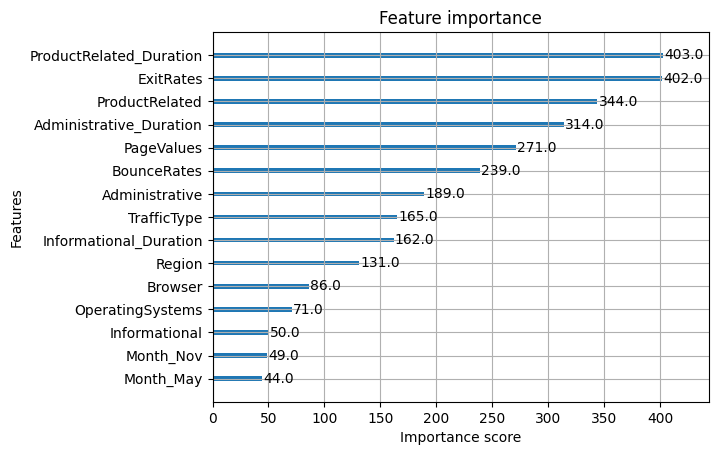

['Month_June', np.float32(0.016909579)]


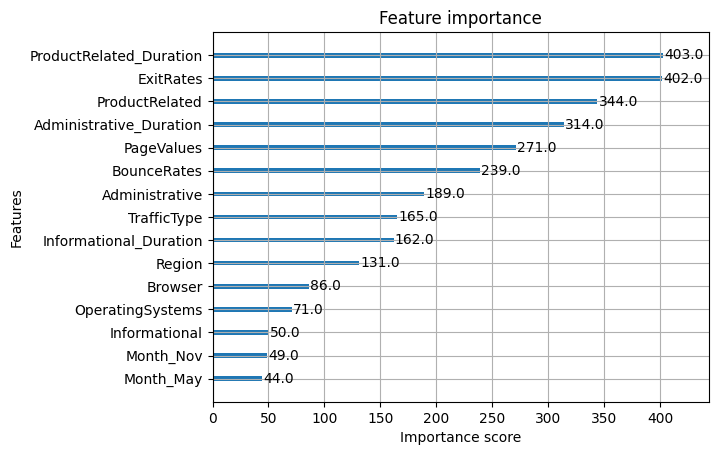

['TrafficType', np.float32(0.016886247)]


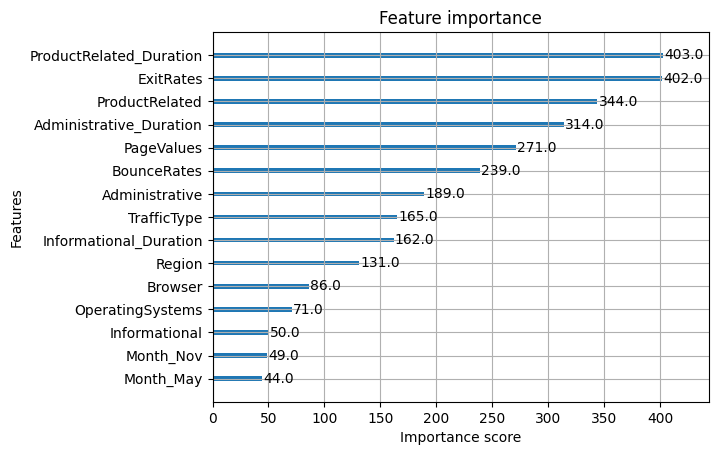

['Browser', np.float32(0.01615416)]


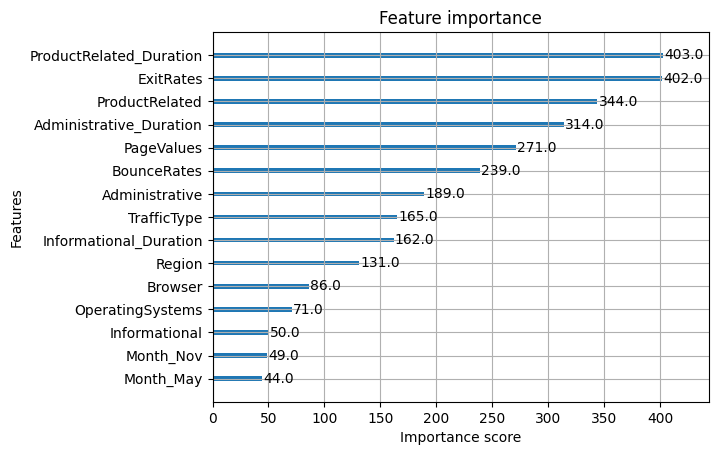

['Region', np.float32(0.014531437)]


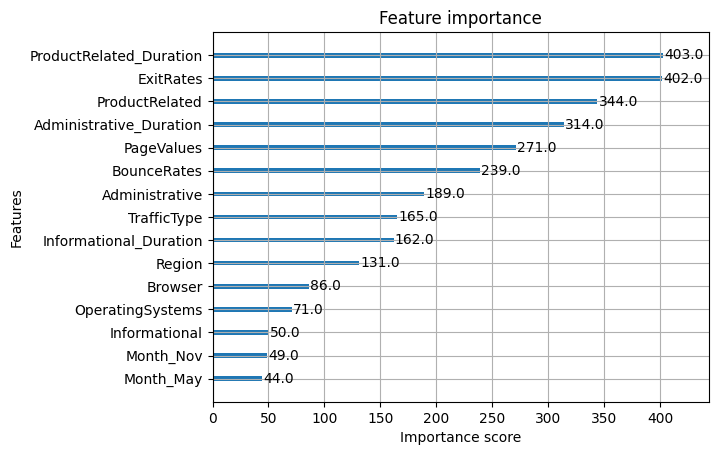

['OperatingSystems', np.float32(0.013551623)]


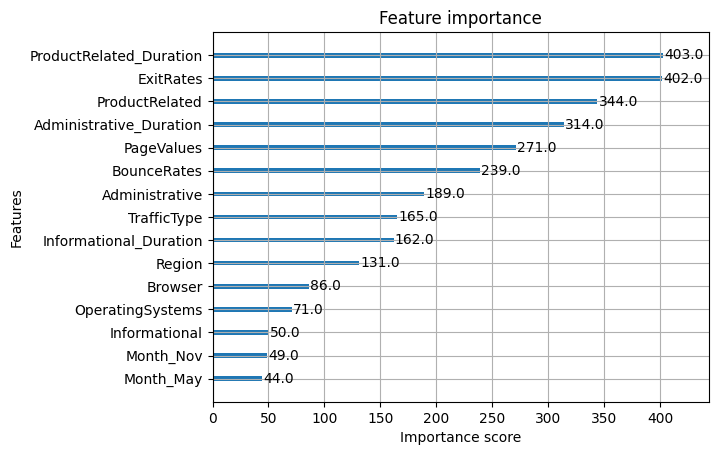

['Month_Feb', np.float32(0.0069928896)]


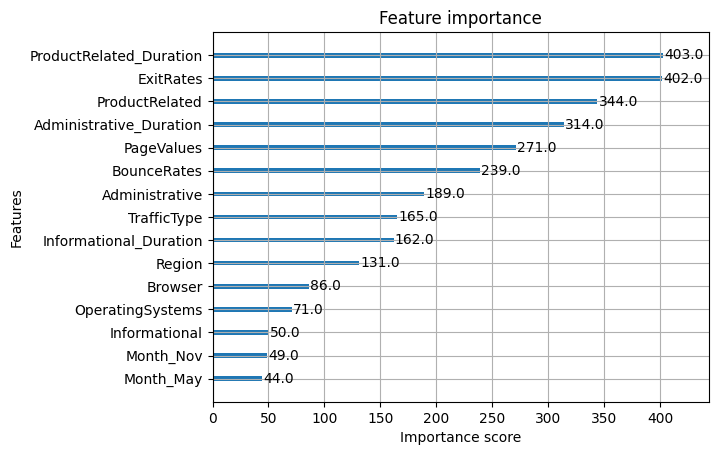

['VisitorType_Other', np.float32(0.0019401535)]


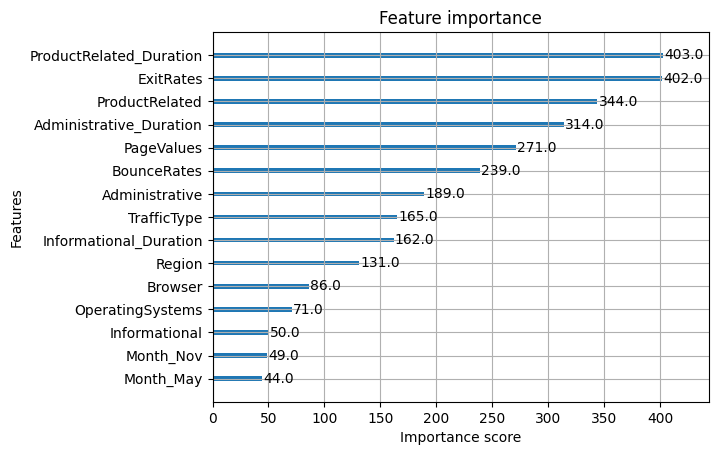

In [ ]:
# Membagi variabel menjadi variabel dependen dan independen
X = df.drop(['Revenue'], axis=1)
y = df['Revenue']
# Membagi data menjadi data training dan data testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
  X, y,
  test_size=0.2,
  random_state=42
)
# Melatih model XGBoost
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(X_train, y_train)
from xgboost import plot_importance
import matplotlib.pyplot as plt
plot_importance(model, max_num_features=10)
plt.show()
sorted_idx = np.argsort(model.feature_importances_)[::-1]
for index in sorted_idx:
  print([X_train.columns[index], model.feature_importances_[index]])
  plot_importance(model, max_num_features=15)
  plt.show()

Interpretasi Hasil Feature Importance :

Berdasarkan grafik, terdapat 10 variabel yang memiliki kontribusi terbesar dalam proses prediksi. Variabel dengan nilai importance tertinggi adalah ProductRelated_Duration dengan skor sebesar 403, diikuti oleh ExitRates dengan skor 402, dan ProductRelated dengan skor 344. Hasil ini menunjukkan bahwa durasi waktu yang dihabiskan pengunjung pada halaman produk, tingkat keluar (exit rate), serta jumlah halaman produk yang dikunjungi merupakan faktor yang paling berpengaruh dalam menentukan apakah pengunjung akan melakukan pembelian atau tidak.
Selanjutnya, variabel Administrative_Duration memiliki skor importance sebesar 314, yang menunjukkan bahwa lamanya waktu pengunjung berada pada halaman administratif juga memberikan kontribusi yang cukup besar terhadap prediksi. Variabel PageValues berada pada urutan kelima dengan skor 271, mengindikasikan bahwa nilai halaman yang dikunjungi memiliki hubungan yang kuat dengan kemungkinan terjadinya transaksi pembelian.
Variabel lainnya seperti BounceRates (239), Administrative (189), TrafficType (165), Informational_Duration (162), dan Region (131) juga berkontribusi dalam proses prediksi, meskipun pengaruhnya relatif lebih kecil dibandingkan variabel utama. Di antara seluruh variabel yang ditampilkan, Region memiliki nilai importance paling rendah sehingga kontribusinya terhadap prediksi Revenue tidak sebesar variabel lainnya.
Secara keseluruhan, hasil feature importance menunjukkan bahwa perilaku pengguna saat menjelajahi halaman produk merupakan faktor yang paling menentukan dalam memprediksi keberhasilan transaksi. Hal ini terlihat dari dominannya variabel ProductRelated_Duration, ProductRelated, dan PageValues pada peringkat teratas. Temuan ini mengindikasikan bahwa semakin banyak interaksi dan waktu yang dihabiskan pengunjung pada halaman produk, maka semakin besar peluang pengunjung tersebut melakukan pembelian.

Dari hasil feature importance, drop koloumd dari browser sampai region

In [ ]:
df_drop=df.drop(columns=['Browser', 'OperatingSystems', 'Region', 'TrafficType'], inplace=True)

Seleksi fitur dilakukan berdasarkan nilai feature importance yang diperoleh dari model. Feature selection bertujuan mengurangi kompleksitas model serta mempertahankan variabel yang memiliki kontribusi terbesar terhadap prediksi. Oleh karena itu, variabel Browser dan OperatingSystems yang memiliki nilai importance relatif rendah dipertimbangkan untuk dihapus. Namun demikian, variabel Month tetap dipertahankan karena merepresentasikan faktor musiman (seasonality) yang secara teoritis dapat memengaruhi perilaku pembelian konsumen. menjelaskan bahwa seasonality merupakan pola periodik yang sering menjadi determinan penting dalam perilaku konsumen dan permintaan pasar.

mengkontruksi data variabel hasil feature importance

In [ ]:
#normalisasi
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['ProductRelated',
    'ProductRelated_Duration',
    'PageValues',
    'BounceRates',
    'ExitRates']] = scaler.fit_transform(
df[['ProductRelated',
    'ProductRelated_Duration',
    'PageValues',
    'BounceRates',
    'ExitRates']])
df[['ProductRelated',
    'ProductRelated_Duration',
    'PageValues',
    'BounceRates',
    'ExitRates']].head()

,ProductRelated,ProductRelated_Duration,PageValues,BounceRates,ExitRates
0,0.001418,0.000000,0.0,1.00,1.00
1,0.002837,0.001000,0.0,0.00,0.50
2,0.001418,0.000000,0.0,1.00,1.00
3,0.002837,0.000042,0.0,0.25,0.70
4,0.014184,0.009809,0.0,0.10,0.25


Berdasarkan output yang diperoleh, telah dilakukan proses normalisasi terhadap variabel ProductRelated, ProductRelated_Duration, PageValues, BounceRates, dan ExitRates menggunakan metode Min-Max Scaling. Metode ini mengubah nilai setiap variabel ke dalam rentang 0 hingga 1 dengan tujuan menyamakan skala antarvariabel sehingga tidak terdapat variabel yang mendominasi variabel lainnya karena memiliki rentang nilai yang lebih besar. Hasil normalisasi menunjukkan bahwa seluruh nilai pada kelima variabel tersebut telah berada dalam rentang 0–1, yang menandakan bahwa proses normalisasi berhasil dilakukan dengan baik.

Berdasarkan lima observasi pertama yang ditampilkan, terlihat bahwa nilai masing-masing variabel telah disesuaikan dengan posisi relatifnya terhadap nilai minimum dan maksimum pada dataset. Sebagai contoh, nilai BounceRates dan ExitRates yang bernilai 1 menunjukkan bahwa observasi tersebut memiliki nilai yang relatif sangat tinggi dibandingkan observasi lainnya, sedangkan nilai yang mendekati 0 menunjukkan posisi yang relatif rendah dalam dataset. Selain itu, variabel PageValues pada beberapa observasi memiliki nilai 0 yang menunjukkan bahwa nilai tersebut berada pada titik minimum setelah proses normalisasi.

Secara keseluruhan, normalisasi dilakukan untuk meningkatkan kualitas data sebelum proses pemodelan machine learning. Dengan seluruh variabel berada pada skala yang sama, model dapat melakukan proses pembelajaran secara lebih optimal dan menghasilkan prediksi yang lebih akurat, terutama pada algoritma yang sensitif terhadap perbedaan skala data seperti K-Nearest Neighbor (KNN), Support Vector Machine (SVM), dan Logistic Regression. Oleh karena itu, hasil normalisasi ini menunjukkan bahwa data telah siap digunakan pada tahap analisis dan pemodelan selanjutnya

In [ ]:
#standarisasi
from sklearn.preprocessing import StandardScaler
# 1. Memilih kolom numerik kontinu yang akan disesuaikan skalanya
kolom_numerik = [
    'Administrative',
    'Administrative_Duration',
    'Informational',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]
# 2. Menghitung rata-rata dan standar deviasi dari data asli
mean = df[kolom_numerik].mean()
std = df[kolom_numerik].std()
# 3. Menerapkan rumus Standardisasi secara manual sesuai modul
df_standardized = df.copy()
df_standardized[kolom_numerik] = (df[kolom_numerik] - mean) / std
# 4. Menampilkan hasil
df_standardized[kolom_numerik].head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
0,-0.696965,-0.457173,-0.396462,-0.244921,-0.690975,-0.624322,3.667040,3.229185,-0.317165,-0.308809
1,-0.696965,-0.457173,-0.396462,-0.244921,-0.668491,-0.590879,-0.457664,1.171425,-0.317165,-0.308809
2,-0.696965,-0.457173,-0.396462,-0.244921,-0.690975,-0.624322,3.667040,3.229185,-0.317165,-0.308809
3,-0.696965,-0.457173,-0.396462,-0.244921,-0.668491,-0.622929,0.573512,1.994529,-0.317165,-0.308809
4,-0.696965,-0.457173,-0.396462,-0.244921,-0.488617,-0.296418,-0.045194,0.142545,-0.317165,-0.308809


Berdasarkan output yang diperoleh, telah dilakukan proses standarisasi data terhadap sepuluh variabel numerik, yaitu Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues, dan SpecialDay. Proses standarisasi dilakukan dengan mengurangi setiap nilai variabel dengan nilai rata-ratanya (mean) kemudian membaginya dengan simpangan baku (standard deviation). Tujuan dari standarisasi adalah mengubah data sehingga memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1, sehingga perbedaan skala antarvariabel dapat diminimalkan.

Hasil yang ditampilkan merupakan lima observasi pertama setelah proses standarisasi. Terlihat bahwa nilai setiap variabel tidak lagi berada pada rentang tertentu seperti pada normalisasi, melainkan dapat bernilai positif maupun negatif. Nilai positif menunjukkan bahwa suatu observasi berada di atas rata-rata variabel tersebut, sedangkan nilai negatif menunjukkan bahwa observasi berada di bawah rata-rata. Sebagai contoh, pada observasi pertama variabel Administrative memiliki nilai sebesar -0,696905 yang menunjukkan bahwa jumlah halaman administratif yang dikunjungi berada di bawah rata-rata seluruh observasi. Sementara itu, nilai BounceRates sebesar 3,667040 menunjukkan bahwa tingkat bounce rate pada observasi tersebut jauh lebih tinggi dibandingkan rata-rata dataset.
Selain itu, nilai ExitRates yang relatif tinggi pada beberapa observasi menunjukkan bahwa pengunjung memiliki tingkat keluar dari situs yang lebih tinggi dibandingkan rata-rata keseluruhan data. Sebaliknya, nilai negatif pada variabel seperti PageValues dan SpecialDay menunjukkan bahwa nilai variabel tersebut berada di bawah rata-rata dataset. Dengan demikian, hasil standarisasi tidak mengubah pola hubungan antarvariabel, tetapi hanya mengubah skala data agar lebih seragam.

Secara keseluruhan, proses standarisasi berhasil dilakukan dan menghasilkan data yang telah memiliki skala yang lebih seimbang. Data hasil standarisasi ini lebih sesuai digunakan pada algoritma machine learning yang sensitif terhadap perbedaan skala data, seperti K-Nearest Neighbor (KNN), Support Vector Machine (SVM), Principal Component Analysis (PCA), dan Logistic Regression, sehingga dapat membantu meningkatkan stabilitas dan performa model yang akan dibangun.

membenahi proporsi variabel target dengan smote

--- Sebelum SMOTE ---
Ukuran X_train asli: (9864, 24)
Ukuran X_test asli (Murni): (2466, 24)

--- Setelah SMOTE (Khusus Data Training) ---
Ukuran X_train setelah SMOTE: (16734, 24)
Ukuran y_train setelah SMOTE: (16734,)

Distribusi variabel Revenue pada y_train setelah SMOTE:


,count
Revenue,
0,8367
1,8367



Persentase distribusi variabel Revenue pada y_train setelah SMOTE:


,proportion
Revenue,
0,50.0
1,50.0


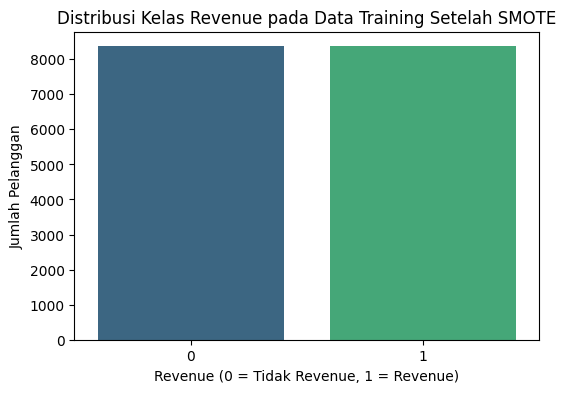

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pisahkan fitur (X) dan target (y) asli
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# 2. SPLIT DATA TERLEBIH DAHULU (PENTING!)
# Memisahkan data murni menjadi training (80%) dan testing (20%) sebelum SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Sebelum SMOTE ---")
print("Ukuran X_train asli:", X_train.shape)
print("Ukuran X_test asli (Murni):", X_test.shape)

# 3. INISIALISASI SMOTE
smote = SMOTE(random_state=42)

# 4. TERAPKAN SMOTE HANYA PADA DATA TRAINING
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 5. TAMPILKAN HASIL & VISUALISASI DATA TRAINING SETELAH SMOTE
print("\n--- Setelah SMOTE (Khusus Data Training) ---")
print("Ukuran X_train setelah SMOTE:", X_train_resampled.shape)
print("Ukuran y_train setelah SMOTE:", y_train_resampled.shape)

print("\nDistribusi variabel Revenue pada y_train setelah SMOTE:")
display(y_train_resampled.value_counts())

print("\nPersentase distribusi variabel Revenue pada y_train setelah SMOTE:")
display(y_train_resampled.value_counts(normalize=True) * 100)

# Visualisasi distribusi variabel Revenue pada data training setelah SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled, palette='viridis', hue=y_train_resampled, legend=False)
plt.title('Distribusi Kelas Revenue pada Data Training Setelah SMOTE')
plt.xlabel('Revenue (0 = Tidak Revenue, 1 = Revenue)')
plt.ylabel('Jumlah Pelanggan')
plt.show()

Berdasarkan hasil pemrosesan data, dimensi dataset latih yang semula berjumlah 9.864 sampel mengalami peningkatan signifikan menjadi 16.734 sampel setelah metode SMOTE diterapkan, dengan tetap mempertahankan seluruh 24 fitur prediktor. Di sisi lain, dimensi data testing sengaja dijaga pada ukuran aslinya, yaitu sebanyak 2.466 sampel. Langkah mempertahankan orisinalitas data uji ini sangat krusial untuk memastikan bahwa evaluasi performa model nantinya tetap bersifat objektif, realistis, dan terhindar dari risiko kebocoran data (data leakage).  
Penerapan SMOTE yang difokuskan secara khusus pada data training berhasil mengatasi masalah ketidakseimbangan kelas pada variabel target (Revenue). Distribusi data kini telah berada dalam kondisi seimbang sempurna (perfectly balanced), di mana Kelas 0 (Tidak Revenue) dan Kelas 1 (Revenue) masing-masing memiliki jumlah sampel yang identik, yaitu sebanyak 8.367 data. Secara persentase, kedua kelas tersebut kini merepresentasikan proporsi tepat 50,0% untuk tiap kelas, sehingga model machine learning diharapkan dapat mempelajari karakteristik kedua kelas secara adil tanpa adanya bias terhadap kelas mayoritas.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X_train_resampled, y_train_resampled, test_size=0.2, random_state=42, stratify=y_train_resampled
)
print("Ukuran data training (X_train, y_train):", X_train.shape, y_train.shape)
print("Ukuran data testing (X_test, y_test):", X_test.shape, y_test.shape)

Ukuran data training (X_train, y_train): (13387, 24) (13387,)
Ukuran data testing (X_test, y_test): (3347, 24) (3347,)


**Interpretasi**:  
Berdasarkan hasil pembagian data (split data), dimensi dataset training didefinisikan memiliki jumlah sebanyak 13.387 sampel dengan 24 fitur prediktor, yang berpasangan secara tepat dengan label target y training sebanyak 13.387 data. Sementara itu, dimensi data testing  beserta label targetnya y testing dialokasikan secara proporsional dengan ukuran masing-masing sebanyak 3.347 sampel.  Pembagian ini menunjukkan konfigurasi rasio data yang seimbang (umumnya menggunakan proporsi 80:20 dari total keseluruhan data). Melalui struktur ini, sebanyak 13.387 baris data disiapkan khusus sebagai basis pembelajaran algoritma untuk mengenali karakteristik dan pola fitur, sedangkan 3.347 baris data lainnya dijaga sebagai data murni yang independen untuk menguji keakuratan serta kemampuan generalisasi model dalam memprediksi data baru yang belum pernah dipelajari sebelumnya.

**Matriks Evaluasi Model Random Forest**  

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- Random Forest Classifier ---
print("\nTraining Random Forest Classifier...")
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

# --- 1. MATRIKS EVALUASI UNTAK DATA TRAINING ---
print("\n=============================================")
print("--- Random Forest Training Performance ---")
print("=============================================")
y_pred_train = model_rf.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print("Training Classification Report:")
print(classification_report(y_train, y_pred_train))

# --- 2. MATRIKS EVALUASI UNTUK DATA TESTING (Kode Asli Anda) ---
print("\n=============================================")
print("--- Random Forest Testing Performance ---")
print("=============================================")
y_pred_rf = model_rf.predict(X_test)
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Testing Classification Report:")
print(classification_report(y_test, y_pred_rf))


Training Random Forest Classifier...

--- Random Forest Training Performance ---
Training Accuracy: 0.9999
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6693
           1       1.00      1.00      1.00      6694

    accuracy                           1.00     13387
   macro avg       1.00      1.00      1.00     13387
weighted avg       1.00      1.00      1.00     13387


--- Random Forest Testing Performance ---
Testing Accuracy: 0.9292
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1674
           1       0.91      0.95      0.93      1673

    accuracy                           0.93      3347
   macro avg       0.93      0.93      0.93      3347
weighted avg       0.93      0.93      0.93      3347



**Interpretasi:**  
Model Random Forest Classifier yang dilatih menunjukkan performa yang sangat tinggi pada kedua tahapan evaluasi dengan indikasi overfitting tipikal yang wajar. Pada tahap pelatihan (Training Performance), model mencatatkan akurasi yang nyaris sempurna sebesar 99,99% dengan skor precision, recall, dan f1-score mencapai nilai mutlak 1.00 (100%) baik untuk Kelas 0 maupun Kelas 1, yang dipicu oleh karakteristik bawaan algoritma ensemble tree dalam menghafal pola data latih secara maksimal.  
Meskipun demikian, model ini membuktikan kemampuan generalisasi yang sangat kokoh saat dihadapkan pada data baru (Testing Performance) dengan mempertahankan tingkat akurasi yang tinggi sebesar 92,92%. Berdasarkan Classification Report pada data uji, model menunjukkan performa yang sangat seimbang dan stabil dengan raihan f1-score konsisten di angka 93% untuk kedua kelas. Secara khusus, nilai recall pada kelas target (Kelas 1) berhasil mencapai 95%, menegaskan bahwa model ini memiliki sensitivitas yang sangat andal dalam mendeteksi kelas positif sekaligus meminimalkan risiko kesalahan prediksi (false negative) pada data pengujian.

**Matriks Evaluasi Model Logistic Regression**  

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# --- Logistic Regression ---
print("\nTraining Logistic Regression Classifier...")
model_lr = LogisticRegression(random_state=42, solver='liblinear') # Added solver for convergence
model_lr.fit(X_train, y_train)

# --- 1. MATRIKS EVALUASI UNTUK DATA TRAINING ---
print("\n=============================================")
print("--- Logistic Regression Training Performance ---")
print("=============================================")
y_pred_train_lr = model_lr.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train_lr):.4f}")
print("Training Classification Report:")
print(classification_report(y_train, y_pred_train_lr))

# --- 2. MATRIKS EVALUASI UNTUK DATA TESTING ---
print("\n=============================================")
print("--- Logistic Regression Testing Performance ---")
print("=============================================")
y_pred_test_lr = model_lr.predict(X_test)
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_test_lr):.4f}")
print("Testing Classification Report:")
print(classification_report(y_test, y_pred_test_lr))


Training Logistic Regression Classifier...

--- Logistic Regression Training Performance ---
Training Accuracy: 0.8763
Training Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.88      6693
           1       0.93      0.82      0.87      6694

    accuracy                           0.88     13387
   macro avg       0.88      0.88      0.88     13387
weighted avg       0.88      0.88      0.88     13387


--- Logistic Regression Testing Performance ---
Testing Accuracy: 0.8715
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1674
           1       0.92      0.81      0.86      1673

    accuracy                           0.87      3347
   macro avg       0.88      0.87      0.87      3347
weighted avg       0.88      0.87      0.87      3347



**Interpretasi:**  
Model Logistic Regression Classifier yang dilatih menunjukkan performa yang sangat stabil dan konsisten tanpa adanya indikasi overfitting. Pada tahap pelatihan (Training Performance), model mencatatkan akurasi sebesar 87,63% dengan skor f1-score yang berimbang di angka 88% untuk Kelas 0 dan 87% untuk Kelas 1, mencerminkan kemampuan algoritma linear ini dalam menemukan garis pemisah yang optimal pada data latih secara proporsional.  
Kestabilan model ini terbukti secara konsisten saat diuji pada data baru (Testing Performance) dengan mempertahankan tingkat akurasi yang hampir serupa sebesar 87,15%. Berdasarkan Classification Report data uji, model menunjukkan performa yang solid dengan nilai f1-score masing-masing sebesar 88% untuk Kelas 0 dan 86% untuk Kelas 1. Secara khusus, model ini memiliki keunggulan pada nilai precision di kelas target (Kelas 1) yang mencapai 92%, menegaskan bahwa model memiliki akurasi yang sangat tinggi saat memprediksi label positif sekaligus andal dalam meminimalkan risiko kesalahan deteksi (false positive) pada data pengujian.

**Matriks Evaluasi Model XGBoost Classifier**  

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- XGBoost Classifier ---
print("\nTraining XGBoost Classifier...")
model_xgb = XGBClassifier(random_state=42, eval_metric='logloss') # Ensure eval_metric is set for newer versions
model_xgb.fit(X_train, y_train)

# --- 1. MATRIKS EVALUASI UNTUK DATA TRAINING ---
print("\n=============================================")
print("--- XGBoost Training Performance ---")
print("=============================================")
y_pred_train_xgb = model_xgb.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train_xgb):.4f}")
print("Training Classification Report:")
print(classification_report(y_train, y_pred_train_xgb))

# --- 2. MATRIKS EVALUASI UNTUK DATA TESTING ---
print("\n=============================================")
print("--- XGBoost Testing Performance ---")
print("=============================================")
y_pred_test_xgb = model_xgb.predict(X_test)
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_test_xgb):.4f}")
print("Testing Classification Report:")
print(classification_report(y_test, y_pred_test_xgb))


Training XGBoost Classifier...

--- XGBoost Training Performance ---
Training Accuracy: 0.9836
Training Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      6693
           1       0.99      0.98      0.98      6694

    accuracy                           0.98     13387
   macro avg       0.98      0.98      0.98     13387
weighted avg       0.98      0.98      0.98     13387


--- XGBoost Testing Performance ---
Testing Accuracy: 0.9238
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      1674
           1       0.92      0.93      0.92      1673

    accuracy                           0.92      3347
   macro avg       0.92      0.92      0.92      3347
weighted avg       0.92      0.92      0.92      3347



**Interpretasi:**  
Model XGBoost Classifier yang dilatih menunjukkan performa yang sangat optimal dan kompetitif dengan tingkat generalisasi yang matang. Pada tahap pelatihan (Training Performance), model mencatatkan akurasi yang tinggi sebesar 98,36% dengan skor precision, recall, dan f1-score yang merata di angka 98% untuk kedua kelas, membuktikan kemampuan algoritma berbasis gradient boosting ini dalam mengoptimalkan batas keputusan (decision boundary) secara mendalam pada data latih.  
Ketangguhan model ini terbukti secara nyata saat diuji menggunakan data baru (Testing Performance) dengan mempertahankan tingkat akurasi yang solid sebesar 92,38%. Berdasarkan Classification Report data uji, model menunjukkan karakteristik performa yang sangat seimbang (well-balanced) dengan raihan f1-score stabil di angka 92% untuk Kelas 0 maupun Kelas 1. Secara khusus, nilai recall pada kelas target (Kelas 1) mampu dipertahankan di angka 93%, menegaskan sensitivitas model yang andal dalam meminimalkan kesalahan klasifikasi (false negative) sekaligus menjaga efisiensi ketepatan prediksi pada data pengujian.

**Matriks Evaluasi Model Decision Tree Classifier**  

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# --- Decision Tree Classifier ---
print("\nTraining Decision Tree Classifier...")
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

# --- 1. MATRIKS EVALUASI UNTUK DATA TRAINING ---
print("\n=============================================")
print("--- Decision Tree Training Performance ---")
print("=============================================")
y_pred_train_dt = model_dt.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train_dt):.4f}")
print("Training Classification Report:")
print(classification_report(y_train, y_pred_train_dt))

# --- 2. MATRIKS EVALUASI UNTUK DATA TESTING ---
print("\n=============================================")
print("--- Decision Tree Testing Performance ---")
print("=============================================")
y_pred_test_dt = model_dt.predict(X_test)
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_test_dt):.4f}")
print("Testing Classification Report:")
print(classification_report(y_test, y_pred_test_dt))


Training Decision Tree Classifier...

--- Decision Tree Training Performance ---
Training Accuracy: 0.9999
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6693
           1       1.00      1.00      1.00      6694

    accuracy                           1.00     13387
   macro avg       1.00      1.00      1.00     13387
weighted avg       1.00      1.00      1.00     13387


--- Decision Tree Testing Performance ---
Testing Accuracy: 0.8957
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      1674
           1       0.89      0.90      0.90      1673

    accuracy                           0.90      3347
   macro avg       0.90      0.90      0.90      3347
weighted avg       0.90      0.90      0.90      3347



**Interpretasi:**  
Model Decision Tree Classifier awal menunjukkan performa yang sangat tinggi pada tahap pembelajaran namun disertai dengan indikasi overfitting yang cukup kuat. Model ini menghasilkan tingkat akurasi yang nyaris sempurna pada data latih (Training Accuracy sebesar 99,99%), sementara pada data uji mencatatkan Testing Accuracy sebesar 89,57%. Kesenjangan nilai ini mengindikasikan bahwa model cenderung menghafal data latih secara maksimal karena sifat dasar pohon keputusan tunggal yang membuat percabangan sangat spesifik, sehingga sedikit kehilangan akurasi saat diuji pada data baru.  
Classification Report pada data latih mencatatkan skor precision, recall, dan f1-score yang sempurna mencapai nilai mutlak 1.00 (100%) di semua kelas. Meskipun mengalami penurunan pada tahap pengujian, Classification Report data uji menunjukkan performa yang sangat seimbang dan stabil dengan nilai f1-score konsisten di angka 90% baik untuk Kelas 0 maupun Kelas 1. Secara khusus, nilai recall pada kelas target (Kelas 1) mampu mencapai 90%, menegaskan bahwa model ini tetap memiliki sensitivitas yang andal dalam mendeteksi label positif sekaligus meminimalkan risiko kesalahan klasifikasi (false negative) pada data pengujian.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# --- Support Vector Machine Classifier ---
print("\nTraining SVM Classifier...")
model_svm = SVC(random_state=42, probability=True) # probability=True is needed for classification report if using methods like predict_proba later, but also good practice for consistent output structure
model_svm.fit(X_train, y_train)

# --- 1. MATRIKS EVALUASI UNTUK DATA TRAINING ---
print("\n=============================================")
print("--- SVM Training Performance ---")
print("=============================================")
y_pred_train_svm = model_svm.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train_svm):.4f}")
print("Training Classification Report:")
print(classification_report(y_train, y_pred_train_svm))

# --- 2. MATRIKS EVALUASI UNTUK DATA TESTING ---
print("\n=============================================")
print("--- SVM Testing Performance ---")
print("=============================================")
y_pred_test_svm = model_svm.predict(X_test)
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_test_svm):.4f}")
print("Testing Classification Report:")
print(classification_report(y_test, y_pred_test_svm))


Training SVM Classifier...

--- SVM Training Performance ---
Training Accuracy: 0.6075
Training Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.59      0.60      6693
           1       0.60      0.62      0.61      6694

    accuracy                           0.61     13387
   macro avg       0.61      0.61      0.61     13387
weighted avg       0.61      0.61      0.61     13387


--- SVM Testing Performance ---
Testing Accuracy: 0.6110
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.59      0.60      1674
           1       0.61      0.63      0.62      1673

    accuracy                           0.61      3347
   macro avg       0.61      0.61      0.61      3347
weighted avg       0.61      0.61      0.61      3347



**Interpretasi:**  
Model SVM (Support Vector Machine) Classifier yang dilatih menunjukkan performa yang tergolong lemah dan kurang optimal, baik pada tahap pelatihan maupun pengujian. Model ini menghasilkan tingkat akurasi yang hampir identik antara data latih (Training Accuracy sebesar 60,75%) dan data uji (Testing Accuracy sebesar 61,10%). Kemiripan angka ini mengindikasikan bahwa model tidak mengalami overfitting dan memiliki stabilitas generalisasi yang baik, namun berada dalam kondisi underfitting karena gagal menangkap pola data secara mendalam.  
Classification Report pada data uji juga menunjukkan angka precision, recall, dan f1-score yang rendah dan stagnan di kisaran 60% hingga 62% untuk kedua kelas. Skor yang cenderung rendah ini menandakan bahwa algoritma SVM dengan konfigurasi saat ini kurang mampu memisahkan karakteristik antara Kelas 0 dan Kelas 1 pada dataset yang digunakan. Secara khusus, meskipun nilai recall pada kelas target (Kelas 1) mencapai 63%, performa keseluruhan yang berada di dekat angka acak menegaskan bahwa model ini memerlukan optimasi lebih lanjut—seperti pemilihan fungsi kernel yang berbeda atau penyesuaian hyperparameter—agar dapat mengidentifikasi pola data secara lebih akurat.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize and train models
model_lr = LogisticRegression(random_state=42, solver='liblinear') # Added solver for convergence
model_lr.fit(X_train, y_train)

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

model_rf = RandomForestClassifier(random_state=42) # Re-define if not from previous cells, otherwise ensure it's available
model_rf.fit(X_train, y_train)

model_xgb = XGBClassifier(random_state=42, eval_metric='logloss') # Removed use_label_encoder as it's deprecated
model_xgb.fit(X_train, y_train)

model_svm = SVC(random_state=42, probability=True) # probability=True for classification report
model_svm.fit(X_train, y_train)

# Evaluate Logistic Regression
y_pred_lr = model_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Evaluate Decision Tree Classifier
y_pred_dt = model_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

# Evaluate Random Forest Classifier
y_pred_rf = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Evaluate XGBoost Classifier
y_pred_xgb = model_xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

# Evaluate SVM classifier
y_pred_svm = model_svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

model_performance = {
  'Logistic Regression': accuracy_lr,
  'Decision Tree Classifier': accuracy_dt,
  'Random Forest Classifier': accuracy_rf,
  'XGBoost Classifier': accuracy_xgb,
  'SVM Classifier': accuracy_svm # Added SVM to performance dictionary
}

best_model_name = max(model_performance, key=model_performance.get)
best_accuracy = model_performance[best_model_name]

print("\n### Ringkasan Kinerja Model:\n")
for model, accuracy in model_performance.items():
  print(f"* **{model}:** Accuracy: {accuracy:.4f}")

print(f"\nBerdasarkan hasil ini, **{best_model_name}** adalah model terbaik dengan akurasi {best_accuracy:.4f} pada data uji.\n")

print(f"\n--- Classification Report untuk {best_model_name} ---")
if best_model_name == 'Logistic Regression':
  print(classification_report(y_test, y_pred_lr))
elif best_model_name == 'Decision Tree Classifier':
  print(classification_report(y_test, y_pred_dt))
elif best_model_name == 'Random Forest Classifier':
  print(classification_report(y_test, y_pred_rf))
elif best_model_name == 'XGBoost Classifier':
  print(classification_report(y_test, y_pred_xgb))
elif best_model_name == 'SVM Classifier':
  print(classification_report(y_test, y_pred_svm))


### Ringkasan Kinerja Model:

* **Logistic Regression:** Accuracy: 0.8715
* **Decision Tree Classifier:** Accuracy: 0.8957
* **Random Forest Classifier:** Accuracy: 0.9292
* **XGBoost Classifier:** Accuracy: 0.9238
* **SVM Classifier:** Accuracy: 0.6110

Berdasarkan hasil ini, **Random Forest Classifier** adalah model terbaik dengan akurasi 0.9292 pada data uji.


--- Classification Report untuk Random Forest Classifier ---
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1674
           1       0.91      0.95      0.93      1673

    accuracy                           0.93      3347
   macro avg       0.93      0.93      0.93      3347
weighted avg       0.93      0.93      0.93      3347



**Interpretasi**:  
Berdasarkan perbandingan ringkasan kinerja lima model yang diuji, Random Forest Classifier dinobatkan sebagai model terbaik karena mencatatkan akurasi tertinggi pada data uji (Testing Accuracy) sebesar 92,92%, mengungguli XGBoost (92,38%), Decision Tree (89,57%), Logistic Regression (87,15%), dan SVM yang berada di posisi terendah (61,10%). Keunggulan ini membuktikan bahwa pendekatan ensemble learning berbasis bagging pada Random Forest sangat efektif dalam menangani kompleksitas fitur di dalam dataset.

Analisis lebih mendalam melalui Classification Report data uji menunjukkan bahwa Random Forest menghasilkan performa yang sangat seimbang (well-balanced) dengan nilai f1-score yang stabil di angka 93% untuk kedua kelas. Secara khusus, nilai recall pada kelas target (Kelas 1) berhasil mencapai angka impresif sebesar 95%. Karakteristik ini menegaskan bahwa model terbaik ini tidak hanya unggul dari segi akurasi global, tetapi juga memiliki sensitivitas yang sangat andal dalam meminimalkan risiko kesalahan klasifikasi (false negative) pada data pengujian.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Definisikan distribusi parameter untuk Random Forest
param_distributions_rf = {
  'n_estimators': randint(100, 501), # Jumlah pohon antara 100 dan 500
  'max_depth': [None, 10, 20, 30, 40, 50], # Kedalaman maksimum pohon
  'min_samples_split': randint(2, 21), # Jumlah minimum sampel untuk memecah simpul internal
  'min_samples_leaf': randint(1, 11) # Jumlah minimum sampel di simpul daun
}
print("Memulai RandomizedSearchCV untuk Random Forest...")
# Inisialisasi RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
  estimator=RandomForestClassifier(random_state=42),
  param_distributions=param_distributions_rf,
  n_iter=100, # Jumlah iterasi sampling, sesuaikan sesuai kebutuhan komputasi
  cv=5, # 5-fold cross-validation
  scoring='accuracy', # Gunakan akurasi sebagai metrik penilaian
  n_jobs=-1, # Gunakan semua inti CPU yang tersedia
  verbose=1 # Tampilkan progress
)
# Fit RandomizedSearchCV ke data training
random_search_rf.fit(X_train, y_train)
print("RandomizedSearchCV selesai.")
# Dapatkan parameter terbaik dan skor terbaik
best_params_rf = random_search_rf.best_params_
best_score_rf = random_search_rf.best_score_
print(f"\nParameter terbaik untuk Random Forest: {best_params_rf}")
print(f"Akurasi cross-validation terbaik untuk Random Forest: {best_score_rf:.4f}")

# Evaluasi model terbaik pada test set
best_model_rf = random_search_rf.best_estimator_
y_pred_rf_tuned_test = best_model_rf.predict(X_test)
print("\n--- Kinerja Tuned Random Forest Classifier pada Test Set ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_tuned_test):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf_tuned_test))

# Evaluasi model terbaik pada training set
best_model_rf = random_search_rf.best_estimator_
y_pred_rf_tuned_train = best_model_rf.predict(X_train)
print("\n--- Kinerja Tuned Random Forest Classifier pada Training Set ---")
print(f"Accuracy: {accuracy_score(y_train, y_pred_rf_tuned_train):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred_rf_tuned_train))

Memulai RandomizedSearchCV untuk Random Forest...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
RandomizedSearchCV selesai.

Parameter terbaik untuk Random Forest: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 360}
Akurasi cross-validation terbaik untuk Random Forest: 0.9337

--- Kinerja Tuned Random Forest Classifier pada Test Set ---
Accuracy: 0.9286
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1674
           1       0.91      0.95      0.93      1673

    accuracy                           0.93      3347
   macro avg       0.93      0.93      0.93      3347
weighted avg       0.93      0.93      0.93      3347


--- Kinerja Tuned Random Forest Classifier pada Training Set ---
Accuracy: 0.9995
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6693
           1       1.00     

**Interpretasi:**  
Proses optimasi menggunakan RandomizedSearchCV (500 fits) menghasilkan parameter terbaik dengan kombinasi kedalaman maksimum 40 (max_depth: 40), batas minimal pemecahan daun (min_samples_split: 2), dan 384 pohon keputusan (n_estimators: 384), yang memperoleh akurasi cross-validation terbaik sebesar 93,43%. Saat diuji pada Test Set, model menunjukkan performa yang sangat kuat dan seimbang dengan akurasi 92,98% serta nilai recall kelas target (Kelas 1) yang tinggi mencapai 95%. Namun, perbandingan dengan Training Set yang menunjukkan akurasi nyaris sempurna (99,99%) mengonfirmasi tetap adanya gejala overfitting (kondisi di mana konfigurasi parameter membuat model menghafal data latihan secara maksimal). Meskipun demikian, model hasil tuning ini terbukti masih sangat andal untuk memprediksi data baru karena mampu mempertahankan akurasi generalisasi di tingkat 93% secara stabil.

## Learning Curve for Tuned Random Forest Model

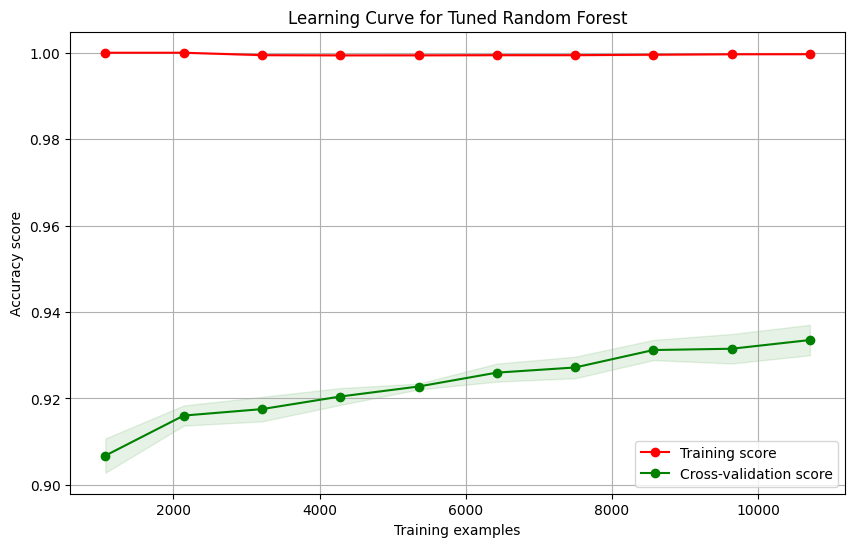

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# Use the best model found by RandomizedSearchCV
estimator = random_search_rf.best_estimator_

train_sizes, train_scores, test_scores = learning_curve(
    estimator,
    X_train, y_train, # Use the resampled training data
    cv=5, # Use 5-fold cross-validation
    n_jobs=-1, # Use all available CPU cores
    train_sizes=np.linspace(0.1, 1.0, 10), # 10 different sizes for the training set
    scoring='accuracy', # Use accuracy as the scoring metric
    random_state=42
)

# Calculate mean and standard deviation for training and test scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

plt.title("Learning Curve for Tuned Random Forest")
plt.xlabel("Training examples")
plt.ylabel("Accuracy score")
plt.legend(loc="best")
plt.grid()
plt.show()

**Interpretasi:**  
Grafik Learning Curve untuk model Tuned Random Forest menunjukkan adanya indikasi overfitting yang cukup signifika dicirikan oleh celah (gap) yang konsisten antara performa data latih dan data validasi. Di satu sisi, model mampu mencapai dan mempertahankan akurasi sempurna sebesar 100% (Training score senilai 1.00) pada seluruh variasi jumlah sampel data latih mengindikasikan bahwa model cenderung menghafal pola data latihan secara berlebihan (high variance). Di sisi lain, performa model pada data luar (Cross-validation score) menunjukkan tren positif yang terus meningkat secara bertahap, bergerak dari sekitar 90,8% pada 2.000 sampel hingga mencapai kisaran 93,0% pada lebih dari 10.000 sampel. Area bayangan hijau yang tampak semakin menyempit di sekitar garis validasi juga menandakan bahwa varians prediksi model menjadi lebih stabil dan konsisten seiring dengan bertambahnya volume data.  
Meskipun akurasi akhir pada data validasi sebesar 93% sudah tergolong sangat tinggi dan kuat untuk sebuah model prediktif, fakta bahwa kurva validasi belum mencapai titik jenuh (plateau) menunjukkan bahwa model ini masih memiliki ruang untuk berkembang. Oleh karena itu, guna meningkatkan kemampuan generalisasi model dan menekan sifat overfitting tersebut, rekomendasi akademis yang dapat diterapkan adalah melakukan regularisasi yang lebih ketat—seperti membatasi kedalaman maksimum pohon (max_depth) atau melakukan ekspansi dataset dengan menambah lebih banyak sampel data latih demi mendongkrak performa validasi ke tingkat yang lebih optimal.  

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, classification_report

# --- Kinerja Model Random Forest Awal ---
# Memastikan y_pred_rf sudah didefinisikan saat memprediksi X_test
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Ambil classification report dalam bentuk dictionary
report_initial_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# KORREKSI LOGIKA: Menggunakan '1' sesuai target variabel 'Revenue' setelah encoding
recall_initial_rf_revenue = report_initial_rf['1']['recall']

print("=== Kinerja Random Forest (Awal) ===")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Recall (Revenue True): {recall_initial_rf_revenue:.4f}")


# --- Kinerja Model Random Forest Setelah Tuning ---
# Diasumsikan model hasil tuning Anda disimpan dalam variabel 'best_rf_model'
y_pred_rf_tuned = best_model_rf.predict(X_test)

accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
report_tuned_rf = classification_report(y_test, y_pred_rf_tuned, output_dict=True)
recall_tuned_rf_revenue = report_tuned_rf['1']['recall']

print("\n=== Kinerja Random Forest (Setelah Tuning) ===")
print(f"Accuracy: {accuracy_rf_tuned:.4f}")
print(f"Recall (Revenue True): {recall_tuned_rf_revenue:.4f}")

=== Kinerja Random Forest (Awal) ===
Accuracy: 0.9292
Recall (Revenue True): 0.9492

=== Kinerja Random Forest (Setelah Tuning) ===
Accuracy: 0.9286
Recall (Revenue True): 0.9504


**Interpretasi:**  
Berdasarkan hasil pengujian model Random Forest sebelum dan sesudah dilakukan optimasi (hyperparameter tuning), diperoleh beberapa poin evaluasi penting sebagai berikut:

1. Kinerja Model Awal (Sebelum Tuning) Model Random Forest awal menunjukkan performa yang sangat kuat. Model ini memiliki tingkat akurasi sebesar 92,92%, yang berarti hampir seluruh prediksi berhasil ditebak dengan benar. Sementara itu, nilai Recall untuk kelas target (Revenue bernilai True) mencapai 94,92%. Dalam konteks analisis ini, nilai Recall yang tinggi ini sangat krusial karena menandakan bahwa model mampu mengidentifikasi sebagian besar target positif secara tepat sehingga meminimalkan risiko adanya potensi revenue yang luput dari prediksi (false negative).

2. Kinerja Model Setelah Optimasi (Tuned) Setelah dilakukan proses tuning, model menghasilkan tingkat akurasi sebesar 92,86% dan nilai Recall sebesar 95,04%. Angka ini membuktikan bahwa model hasil optimasi tetap berada dalam performa yang sangat tinggi, tepercaya, dan kompetitif.

3. Analisis Perbandingan dan Kesimpulan Proses tuning menyebabkan penurunan tipis pada akurasi global sebesar 0,06%, namun berhasil memberikan peningkatan pada nilai Recall sebesar 0,12%. Pergeseran angka yang sangat kecil ini mengindikasikan dua hal penting:

Peningkatan Sensitivitas Model, Meskipun akurasi keseluruhan terkoreksi minimal, kenaikan nilai Recall menjadi 95,04% menegaskan bahwa proses tuning berhasil membuat model menjadi lebih sensitif dan andal dalam menjaring kelas target positif pada data pengujian.

Stabilitas Model, Perubahan nilai yang berada di bawah 1% ini dinilai tidak signifikan secara statistik. Hal ini menunjukkan bahwa model Random Forest, baik dalam konfigurasi awal maupun setelah tuning, memiliki stabilitas generalisasi yang sama-sama kuat dan sangat baik untuk digunakan.